# Early COVID-19 Data Analysis

### A historical analytical snapshot from the first months of the pandemic

**NYU Stern Data Bootcamp · Spring 2020**  
**Analysis period:** primarily through May 12–13, 2020

---

This notebook is a restored and polished version of a three-person final project originally developed during the first wave of COVID-19 in New York City.

The restoration preserves the original analytical questions, historical data period, and collaborative work while improving presentation, reproducibility, code clarity, and interpretation.

## Project questions

Using Python and publicly available COVID-19 and financial data, the project explored four main questions:

1. Which countries were reporting the highest COVID-19 case counts?
2. How was the pandemic developing across the United States and New York City?
3. Which state-level factors were associated with differences in COVID-19 testing?
4. How did selected financial markets and companies behave during the early months of the pandemic?

Because the analysis was conducted while the pandemic was still unfolding, the results should be interpreted as a historical snapshot rather than a retrospective assessment using later knowledge.

## Analysis roadmap

**01 · Global COVID-19 snapshot**  
Global totals, country rankings, interactive visualizations, geographic patterns, population-adjusted comparisons, and case progression.

**02 · United States**  
State-level case patterns, geographic visualization, and daily case development.

**03 · New York City**  
Daily cases, hospitalizations, deaths, and demographic patterns by age and sex.

**04 · State-level testing regression**  
Exploratory relationships between COVID-19 testing and selected state characteristics.

**05 · Financial-market analysis**  
Major US indices, selected companies, and gold prices during the early pandemic period.

**06 · Limitations & conclusion**  
Historical context, methodological limitations, and key observations.

<br/>

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium import plugins
from folium.plugins import HeatMap

import matplotlib.animation as animation
import matplotlib.ticker as ticker

from IPython.display import display, HTML

In [2]:
# ================================================================
# PROJECT VISUAL IDENTITY
# Derived from the color language of the original Spring 2020 project.
# Keep this cell near the top of the notebook.
# ================================================================

PALETTE = {
    # Editorial base
    "paper": "#F7F4F7",
    "panel_lilac": "#F2ECF6",
    "ink": "#17131F",
    "muted": "#746A78",
    "grid": "#DED5DF",

    # Historical-project visual identity
    "archive_purple": "#AF8BAF",
    "deep_plum": "#552244",

    # Semantic analytical colors
   "confirmed": "#3F6FA0",   # richer archival blue
"deaths": "#9A949C",      # soft neutral grey
"recovered": "#F2C14E",   # sunny golden yellow
    "hospitalized": "#00909E",

    # Supporting colors
    "gold": "#F4B942",
    "blue": "#4C78A8",
}

SEMANTIC_COLORS = {
    "Confirmed": PALETTE["confirmed"],
    "Deaths": PALETTE["deaths"],
    "Recovered": PALETTE["recovered"],
    "Hospitalized": PALETTE["hospitalized"],
    "Active": PALETTE["deep_plum"],
}


def section_header(number, title, kicker, signals):
    display(
        HTML(
            f"""
            <div style="
                margin: 32px 0 22px 0;
                border-top: 5px solid {PALETTE['deep_plum']};
                border-bottom: 1px solid {PALETTE['archive_purple']};
                padding: 18px 4px 16px 4px;
            ">
                <div style="
                    font-family: Arial, sans-serif;
                    font-size: 12px;
                    letter-spacing: 2.4px;
                    color: {PALETTE['deep_plum']};
                    font-weight: 700;
                    margin-bottom: 6px;
                ">
                    {number} / {title.upper()}
                </div>

                <div style="
                    font-family: Georgia, serif;
                    font-size: 26px;
                    color: {PALETTE['ink']};
                    line-height: 1.2;
                    margin-bottom: 10px;
                ">
                    {kicker}
                </div>

                <div style="
                    font-family: Arial, sans-serif;
                    font-size: 11px;
                    letter-spacing: 1.3px;
                    color: {PALETTE['muted']};
                ">
                    {signals.upper()}
                </div>
            </div>
            """
        )
    )

In [3]:
section_header(
    "01",
    "Global",
    "The pandemic as it appeared in Spring 2020",
    "reported burden  ·  spatial concentration  ·  population context  ·  temporal progression",
)

The global analysis uses historical COVID-19 data from the Johns Hopkins
University Center for Systems Science and Engineering (JHU CSSE).

To preserve the original Spring 2020 analytical window, the restored notebook
uses locally frozen historical snapshots rather than current versions of the
datasets.

Four JHU datasets support this section:

- `time_series_covid19_confirmed_global.csv` — cumulative reported confirmed
  cases by country/region and province/state;
- `time_series_covid19_deaths_global.csv` — cumulative reported deaths;
- `time_series_covid19_recovered_global.csv` — cumulative reported recoveries;
- `cases_country.csv` — country-level snapshot containing confirmed cases,
  deaths, recoveries, active cases, geographic coordinates, and related metrics.

The time-series data extend through **May 13, 2020**, and the country-level
snapshot was updated on **May 13, 2020 at 23:32:26**.

In [4]:
# Locate the repository whether the kernel starts in the repo root
# or inside the notebooks/ directory.
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate the project data directory.")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
JHU_DATA_DIR = RAW_DATA_DIR / "jhu"

ASSETS_DIR = PROJECT_ROOT / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

# Frozen Johns Hopkins historical snapshots
CoV_deaths = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_deaths_global.csv"
)

CoV_confirmed = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_confirmed_global.csv"
)

CoV_recovered = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_recovered_global.csv"
)

CoV_country = pd.read_csv(
    JHU_DATA_DIR / "cases_country.csv"
)

In [5]:
print("Global deaths:", CoV_deaths.shape)
print("Global confirmed:", CoV_confirmed.shape)
print("Global recovered:", CoV_recovered.shape)
print("Country snapshot:", CoV_country.shape)

print()
print("Time-series through:", CoV_confirmed.columns[-1])
print("Country snapshot updated:", CoV_country["Last_Update"].iloc[0])

Global deaths: (266, 117)
Global confirmed: (266, 117)
Global recovered: (253, 117)
Country snapshot: (188, 14)

Time-series through: 5/13/20
Country snapshot updated: 2020-05-13 23:32:26


### Data preparation

Column names are standardized for consistency while preserving the structure
and historical values of the original datasets.

Missing values are retained where they represent unavailable historical
information rather than being automatically imputed.

In [6]:
# Standardize column names
for df in [CoV_deaths, CoV_confirmed, CoV_recovered, CoV_country]:
    df.columns = df.columns.str.lower()

# Use consistent geographic field names
rename_global = {
    "province/state": "state",
    "country/region": "country",
}

CoV_deaths = CoV_deaths.rename(columns=rename_global)
CoV_confirmed = CoV_confirmed.rename(columns=rename_global)
CoV_recovered = CoV_recovered.rename(columns=rename_global)

CoV_country = CoV_country.rename(
    columns={
        "country_region": "country",
        "long_": "long",
    }
)

display(CoV_country.head())

,country,last_update,lat,long,confirmed,deaths,recovered,active,incident_rate,people_tested,people_hospitalized,mortality_rate,uid,iso3
0,Australia,2020-05-13 23:32:26,-25.0000,133.0000,6979,98,6271,610,27.411949,NaN,NaN,1.404213,36,AUS
1,Austria,2020-05-13 23:32:26,47.5162,14.5501,15997,624,14304,1069,177.618138,NaN,NaN,3.900731,40,AUT
2,Canada,2020-05-13 23:32:26,60.0010,-95.0010,73563,5425,35177,32961,194.324755,NaN,NaN,7.374631,124,CAN
3,China,2020-05-13 23:32:26,30.5928,114.3055,84021,4637,79242,142,5.981520,NaN,NaN,5.518858,156,CHN
4,Denmark,2020-05-13 23:32:26,56.0000,10.0000,10865,533,8861,1471,187.579752,NaN,NaN,4.905660,208,DNK


In [7]:
print(CoV_country.columns.tolist())

['country', 'last_update', 'lat', 'long', 'confirmed', 'deaths', 'recovered', 'active', 'incident_rate', 'people_tested', 'people_hospitalized', 'mortality_rate', 'uid', 'iso3']


In [8]:
assert CoV_confirmed.columns[-1] == "5/13/20"
assert CoV_country["last_update"].iloc[0] == "2020-05-13 23:32:26"

print("Historical JHU inputs loaded and standardized successfully.")

Historical JHU inputs loaded and standardized successfully.


### Global overview

Reported global totals provide a high-level view of the pandemic at the end of
the historical analysis window. The figures below reflect the JHU country-level
snapshot from May 13, 2020.

In [9]:
global_totals = {
    "Confirmed": int(CoV_country["confirmed"].sum()),
    "Deaths": int(CoV_country["deaths"].sum()),
    "Recovered": int(CoV_country["recovered"].sum()),
    "Active": int(CoV_country["active"].sum()),
}

global_totals

{'Confirmed': 4342565,
 'Deaths': 296690,
 'Recovered': 1546811,
 'Active': 2504227}

In [10]:
# Global signal card — restored from the original project's color language

confirmed = global_totals["Confirmed"]
deaths = global_totals["Deaths"]
recovered = global_totals["Recovered"]
active = global_totals["Active"]

display(
    HTML(
        f"""
        <div style="
            background: {PALETTE['panel_lilac']};
            border-top: 6px solid {PALETTE['deep_plum']};
            border-bottom: 1px solid {PALETTE['archive_purple']};
            padding: 22px 26px 24px 26px;
            margin: 20px 0 28px 0;
            font-family: Arial, sans-serif;
        ">

            <!-- Archive header -->
            <div style="
                display: flex;
                justify-content: space-between;
                align-items: baseline;
                margin-bottom: 24px;
            ">
                <div>
                    <div style="
                        font-size: 11px;
                        letter-spacing: 2.2px;
                        color: {PALETTE['deep_plum']};
                        font-weight: 700;
                    ">
                        GLOBAL SIGNAL / HISTORICAL SNAPSHOT
                    </div>

                    <div style="
                        font-family: Georgia, serif;
                        font-size: 21px;
                        color: {PALETTE['ink']};
                        margin-top: 4px;
                    ">
                        Reported COVID-19 burden
                    </div>
                </div>

                <div style="
                    text-align: right;
                    color: {PALETTE['muted']};
                    font-size: 11px;
                    letter-spacing: 1.5px;
                ">
                    13 MAY 2020
                </div>
            </div>

            <!-- Signal values -->
            <div style="
                display: grid;
                grid-template-columns: repeat(4, 1fr);
                column-gap: 22px;
            ">

                <div style="
                    border-top: 4px solid {PALETTE['confirmed']};
                    padding-top: 12px;
                ">
                    <div style="
                        color: {PALETTE['confirmed']};
                        font-size: 11px;
                        letter-spacing: 1.5px;
                        font-weight: 700;
                    ">
                        CONFIRMED
                    </div>
                    <div style="
                        color: {PALETTE['ink']};
                        font-family: Georgia, serif;
                        font-size: 28px;
                        margin-top: 8px;
                        font-variant-numeric: tabular-nums;
                    ">
                        {confirmed:,}
                    </div>
                    <div style="
                        color: {PALETTE['muted']};
                        font-size: 10px;
                        margin-top: 5px;
                    ">
                        reported cumulative cases
                    </div>
                </div>

                <div style="
                    border-top: 4px solid {PALETTE['deaths']};
                    padding-top: 12px;
                ">
                    <div style="
                        color: {PALETTE['deaths']};
                        font-size: 11px;
                        letter-spacing: 1.5px;
                        font-weight: 700;
                    ">
                        DEATHS
                    </div>
                    <div style="
                        color: {PALETTE['ink']};
                        font-family: Georgia, serif;
                        font-size: 28px;
                        margin-top: 8px;
                        font-variant-numeric: tabular-nums;
                    ">
                        {deaths:,}
                    </div>
                    <div style="
                        color: {PALETTE['muted']};
                        font-size: 10px;
                        margin-top: 5px;
                    ">
                        reported cumulative deaths
                    </div>
                </div>

                <div style="
                    border-top: 4px solid {PALETTE['recovered']};
                    padding-top: 12px;
                ">
                    <div style="
                        color: {PALETTE['deep_plum']};
                        font-size: 11px;
                        letter-spacing: 1.5px;
                        font-weight: 700;
                    ">
                        RECOVERED
                    </div>
                    <div style="
                        color: {PALETTE['ink']};
                        font-family: Georgia, serif;
                        font-size: 28px;
                        margin-top: 8px;
                        font-variant-numeric: tabular-nums;
                    ">
                        {recovered:,}
                    </div>
                    <div style="
                        color: {PALETTE['muted']};
                        font-size: 10px;
                        margin-top: 5px;
                    ">
                        reported recoveries
                    </div>
                </div>

                <div style="
                    border-top: 4px solid {PALETTE['deep_plum']};
                    padding-top: 12px;
                ">
                    <div style="
                        color: {PALETTE['deep_plum']};
                        font-size: 11px;
                        letter-spacing: 1.5px;
                        font-weight: 700;
                    ">
                        ACTIVE
                    </div>
                    <div style="
                        color: {PALETTE['ink']};
                        font-family: Georgia, serif;
                        font-size: 28px;
                        margin-top: 8px;
                        font-variant-numeric: tabular-nums;
                    ">
                        {active:,}
                    </div>
                    <div style="
                        color: {PALETTE['muted']};
                        font-size: 10px;
                        margin-top: 5px;
                    ">
                        confirmed − deaths − recovered
                    </div>
                </div>

            </div>

            <!-- Archive annotation -->
            <div style="
                border-top: 1px solid {PALETTE['grid']};
                margin-top: 22px;
                padding-top: 11px;
                color: {PALETTE['muted']};
                font-size: 10px;
                line-height: 1.5;
            ">
                JHU CSSE country-level snapshot · preserved historical reporting window
            </div>

        </div>
        """
    )
)

The May 13 snapshot records reported cumulative cases rather than estimates of
the pandemic's eventual scale. Differences in testing capacity, reporting
practices, and data availability across countries should be considered when
comparing these totals.

### Country-level patterns

Country rankings provide a clearer view of how reported case burden differed
across the most affected countries by May 13, 2020.

The original project explored these patterns through interactive tables,
bubble charts, and bar charts. The restored version consolidates those views
into a single interactive comparison of confirmed cases, deaths, and
recoveries.

In [11]:
print(CoV_country.columns.tolist())

['country', 'last_update', 'lat', 'long', 'confirmed', 'deaths', 'recovered', 'active', 'incident_rate', 'people_tested', 'people_hospitalized', 'mortality_rate', 'uid', 'iso3']


In [12]:
top_confirmed = (
    CoV_country
    .nlargest(10, "confirmed")
    .sort_values("confirmed")
)

top_deaths = (
    CoV_country
    .nlargest(10, "deaths")
    .sort_values("deaths")
)

top_recovered = (
    CoV_country
    .nlargest(10, "recovered")
    .sort_values("recovered")
)

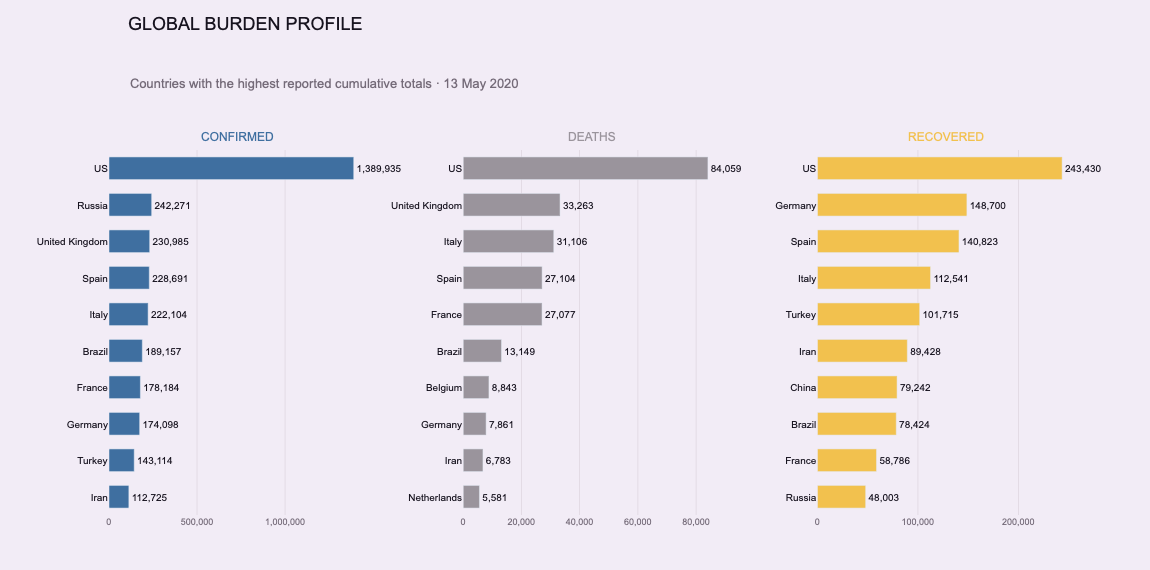

In [13]:
# Global burden profile — use the prepared top-country datasets

confirmed_top = top_confirmed
deaths_top = top_deaths
recovered_top = top_recovered


# Create a fresh three-panel subplot figure
fig = make_subplots(
    rows=1,
    cols=3,
    horizontal_spacing=0.10,
    subplot_titles=[
        "CONFIRMED",
        "DEATHS",
        "RECOVERED",
    ],
)


# Confirmed
fig.add_trace(
    go.Bar(
        x=confirmed_top["confirmed"],
        y=confirmed_top["country"],
        orientation="h",
       marker=dict(
    color=PALETTE["confirmed"],
),
        text=confirmed_top["confirmed"].map(
            lambda x: f"{x:,.0f}"
        ),
        textposition="outside",
        textfont=dict(
            color=PALETTE["ink"],
            size=10,
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Confirmed: %{x:,.0f}"
            "<extra></extra>"
        ),
        cliponaxis=False,
        showlegend=False,
    ),
    row=1,
    col=1,
)


# Deaths
fig.add_trace(
    go.Bar(
        x=deaths_top["deaths"],
        y=deaths_top["country"],
        orientation="h",
       marker=dict(
    color=PALETTE["deaths"],
),
        text=deaths_top["deaths"].map(
            lambda x: f"{x:,.0f}"
        ),
        textposition="outside",
        textfont=dict(
            color=PALETTE["ink"],
            size=10,
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Deaths: %{x:,.0f}"
            "<extra></extra>"
        ),
        cliponaxis=False,
        showlegend=False,
    ),
    row=1,
    col=2,
)


# Recovered
fig.add_trace(
    go.Bar(
        x=recovered_top["recovered"],
        y=recovered_top["country"],
        orientation="h",
        marker=dict(
    color=PALETTE["recovered"],
),
        text=recovered_top["recovered"].map(
            lambda x: f"{x:,.0f}"
        ),
        textposition="outside",
        textfont=dict(
            color=PALETTE["ink"],
            size=10,
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Recovered: %{x:,.0f}"
            "<extra></extra>"
        ),
        cliponaxis=False,
        showlegend=False,
    ),
    row=1,
    col=3,
)


# Editorial layout
fig.update_layout(
 title=dict(
    text="GLOBAL BURDEN PROFILE",
    x=0.02,
     xref="paper",
    xanchor="left",
    y=0.97,
    yanchor="top",
    font=dict(
        family="Arial",
        size=18,
        color=PALETTE["ink"],
    ),
),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=570,
    width=1200,

    margin=dict(
    l=70,
    r=75,
    t=150,
    b=55,
),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),

    bargap=0.38,
)


fig.update_xaxes(
    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,
    zeroline=False,
    tickformat=",",
    tickfont=dict(
        color=PALETTE["muted"],
        size=9,
    ),
    title="",
)


fig.update_yaxes(
    showgrid=False,
    tickfont=dict(
        color=PALETTE["ink"],
        size=10,
    ),
    title="",
)

# Style the three subplot labels
subplot_colors = [
    PALETTE["confirmed"],
    PALETTE["deaths"],
    PALETTE["recovered"],
]

for annotation, color in zip(
    fig.layout.annotations,
    subplot_colors,
):
    annotation.update(
        font=dict(
            family="Arial",
            size=12,
            color=color,
        ),
        y=1.015,  # positions subplot titles above the bars
        yanchor="bottom",
    )

fig.add_annotation(
    text="Countries with the highest reported cumulative totals · 13 May 2020",
    x=0.02,
    y=1.155,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)

fig.show()

The rankings show that the countries with the highest confirmed case counts
were not necessarily ranked identically by deaths or recoveries. These
differences reflect both the progression of outbreaks and substantial
variation in testing, reporting, and recovery definitions across countries.

### Geographic distribution

 The map emphasizes the uneven geographic concentration of reported cases across
the May 13, 2020 snapshot. Larger markers indicate countries with higher
reported confirmed-case totals, with square-root scaling used for visual
readability.

Marker size should not be interpreted as infection prevalence or population-
adjusted risk. Cross-country differences in testing coverage, reporting
practices, population size, and data availability remain important limitations
of the comparison.

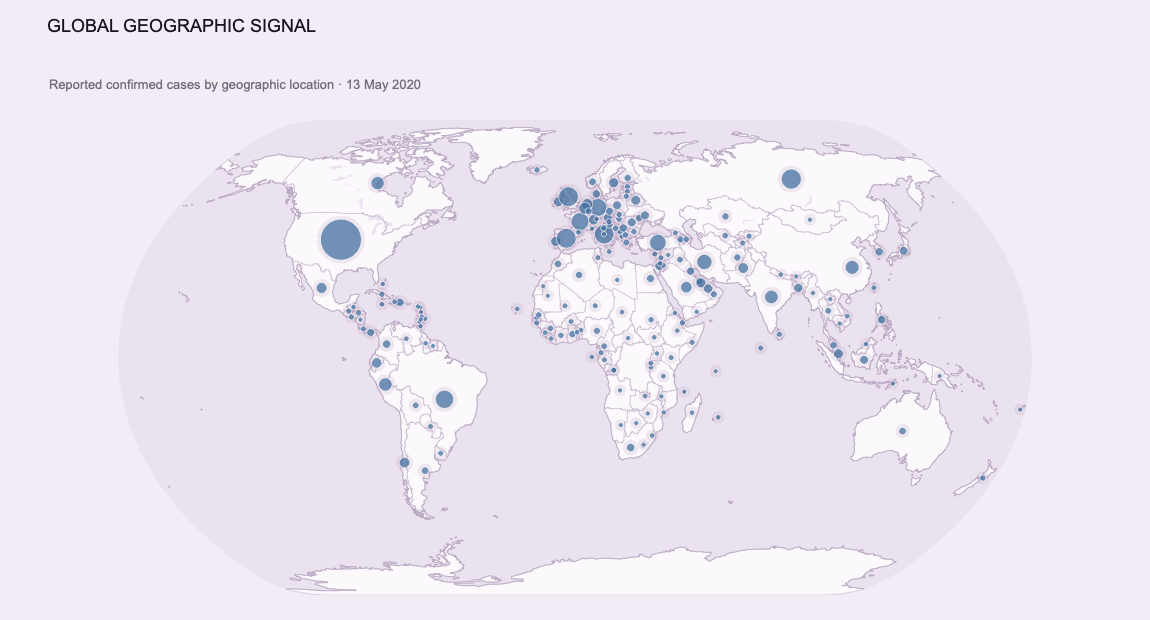

In [14]:
# Geographic distribution of reported confirmed cases

map_data = (
    CoV_country[
        ["country", "lat", "long", "confirmed", "deaths", "recovered"]
    ]
    .dropna(subset=["lat", "long", "confirmed"])
    .copy()
)

map_data = map_data[
    map_data["confirmed"] > 0
].copy()


# Scale marker area using the square root of reported confirmed cases.
# This keeps large totals prominent without allowing them to overwhelm the map.
map_data["marker_size"] = (
    5
    + 36
    * (
        map_data["confirmed"]
        / map_data["confirmed"].max()
    ).pow(0.5)
)


fig = go.Figure()


# Soft archival halo
fig.add_trace(
    go.Scattergeo(
        lon=map_data["long"],
        lat=map_data["lat"],
        mode="markers",
        hoverinfo="skip",
        marker=dict(
            size=map_data["marker_size"] + 7,
            color=PALETTE["archive_purple"],
            opacity=0.16,
            line=dict(width=0),
        ),
        showlegend=False,
    )
)


# Reported confirmed-case markers
fig.add_trace(
    go.Scattergeo(
        lon=map_data["long"],
        lat=map_data["lat"],
        text=map_data["country"],
        customdata=map_data[
            ["confirmed", "deaths", "recovered"]
        ].values,
        mode="markers",
        marker=dict(
            size=map_data["marker_size"],
            color=PALETTE["confirmed"],
            opacity=0.72,
            line=dict(
                color=PALETTE["paper"],
                width=0.8,
            ),
        ),
        hovertemplate=(
            "<b>%{text}</b><br><br>"
            "Confirmed: %{customdata[0]:,.0f}<br>"
            "Deaths: %{customdata[1]:,.0f}<br>"
            "Recovered: %{customdata[2]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)


fig.update_geos(
    projection_type="natural earth",

    showland=True,
    landcolor="#FBF9FC",

    showocean=True,
    oceancolor="#EAE2EF",

    showlakes=True,
    lakecolor="#EAE2EF",

    showcountries=True,
    countrycolor="#CFC1D6",
    countrywidth=0.7,

    showcoastlines=True,
    coastlinecolor="#B9A8C2",
    coastlinewidth=0.8,

    showframe=False,

    bgcolor=PALETTE["panel_lilac"],
)


fig.update_layout(
    title=dict(
        text="GLOBAL GEOGRAPHIC SIGNAL",
        x=0.02,
        xref="paper",
        xanchor="left",
        y=0.97,
        yanchor="top",
        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],

    height=620,
    autosize=True,

    margin=dict(
        l=25,
        r=25,
        t=120,
        b=25,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
)


fig.add_annotation(
    text="Reported confirmed cases by geographic location · 13 May 2020",
    x=0.02,
    y=1.055,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


fig.show()

The map emphasizes the uneven geographic concentration of reported cases rather
than implying that marker size represents true infection prevalence. Cross-country
differences in testing coverage and reporting practices remain important
limitations of the comparison.

### Interactive geographic concentration

The bubble map preserves individual geographic points and relative reported case
burden. The heatmap below shifts the emphasis from individual countries to
broader spatial concentration.

Heat intensity uses square-root-transformed and normalized reported confirmed
case counts. This reduces domination by the largest totals while preserving the
relative ordering of the underlying values.

In [15]:
# Prepare coordinates and reported confirmed cases for the heatmap
heatmap_data = (
    CoV_country[
        ["lat", "long", "confirmed"]
    ]
    .dropna(subset=["lat", "long", "confirmed"])
    .copy()
)

heatmap_data = heatmap_data[
    heatmap_data["confirmed"] > 0
].copy()

# Square-root scaling reduces domination by the largest reported totals
# while preserving their relative ordering.
heatmap_data["heat_weight"] = (
    heatmap_data["confirmed"]
    .clip(lower=0)
    .pow(0.5)
)

# Normalize weights to the 0–1 range expected for visual intensity
heatmap_data["heat_weight"] = (
    heatmap_data["heat_weight"]
    / heatmap_data["heat_weight"].max()
)

heatmap_data.head()

,lat,long,confirmed,heat_weight
0,-25.0000,133.0000,6979,0.070860
1,47.5162,14.5501,15997,0.107281
2,60.0010,-95.0010,73563,0.230055
3,30.5928,114.3055,84021,0.245865
4,56.0000,10.0000,10865,0.088413


In [16]:
# Interactive geographic concentration — Folium heatmap

global_heatmap = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles=None,
    control_scale=True,
    zoom_control=True,
)

# Light cartographic base
folium.TileLayer(
    tiles="CartoDB positron",
    name="Light basemap",
    control=False,
    opacity=0.88,
).add_to(global_heatmap)


# Heat layer
HeatMap(
    heatmap_data[
        ["lat", "long", "heat_weight"]
    ].values.tolist(),
    radius=24,
    blur=13,
    min_opacity=0.30,
    max_zoom=4,
    gradient={
        0.15: "#4338CA",
        0.35: "#2563EB",
        0.50: "#22C55E",
        0.65: "#FDE047",
        0.80: "#F97316",
        1.00: "#DC2626",
    },
).add_to(global_heatmap)


# Editorial title plate
title_html = f"""
<div style="
    position: fixed;
    top: 18px;
    left: 52px;
    z-index: 9999;
    background: rgba(242, 236, 246, 0.94);
    border-top: 4px solid {PALETTE['deep_plum']};
    padding: 12px 16px 11px 16px;
    width: 360px;
    font-family: Arial, sans-serif;
    box-shadow: 0 1px 4px rgba(0,0,0,0.08);
">
    <div style="
        font-size: 15px;
        font-weight: 700;
        color: {PALETTE['ink']};
        letter-spacing: 0.3px;
        margin-bottom: 4px;
    ">
        GLOBAL CASE CONCENTRATION
    </div>

    <div style="
        font-size: 11px;
        color: {PALETTE['muted']};
        line-height: 1.4;
    ">
        Heat intensity from reported confirmed cases · 13 May 2020
    </div>
</div>
"""

global_heatmap.get_root().html.add_child(
    folium.Element(title_html)
)


# Custom heat-intensity legend
legend_html = f"""
<div style="
    position: fixed;
    bottom: 28px;
    right: 28px;
    z-index: 9999;
    background: rgba(242, 236, 246, 0.95);
    padding: 10px 13px 11px 13px;
    border: 1px solid #D5C6DC;
    font-family: Arial, sans-serif;
    width: 190px;
">

    <div style="
        font-size: 10px;
        font-weight: 700;
        color: {PALETTE['deep_plum']};
        letter-spacing: 1px;
        margin-bottom: 7px;
    ">
        REPORTED CASE CONCENTRATION
    </div>

    <div style="
        height: 8px;
        width: 100%;
        background: linear-gradient(
            to right,
            #4338CA,
            #2563EB,
            #22C55E,
            #FDE047,
            #F97316,
            #DC2626
        );
        margin-bottom: 5px;
    "></div>

    <div style="
        display: flex;
        justify-content: space-between;
        font-size: 9px;
        color: {PALETTE['muted']};
    ">
        <span>lower</span>
        <span>higher</span>
    </div>
</div>
"""

global_heatmap.get_root().html.add_child(
    folium.Element(legend_html)
)


# Save interactive artifact
heatmap_path = ASSETS_DIR / "global_case_heatmap.html"

global_heatmap.save(heatmap_path)

print(
    "Interactive heatmap saved to:",
    heatmap_path.relative_to(PROJECT_ROOT),
)

global_heatmap

Interactive heatmap saved to: assets/global_case_heatmap.html


The heatmap highlights the strong geographic concentration of reported cases
across parts of North America and Europe by mid-May 2020, alongside emerging
clusters in other regions.

This view complements the preceding bubble map rather than replacing it. The
bubble map makes individual reported counts easier to compare, while the
heatmap emphasizes broader spatial concentration.

Because testing availability, reporting practices, population size, and the
geographic level represented by each point differed across countries, heat
intensity should not be interpreted as a direct estimate of infection
prevalence or risk.

### Population-adjusted comparison

Raw case counts can obscure differences in country size. To add context, the
original project compared reported confirmed cases with 2018 population data
from the World Bank.

The restored analysis retains the same eight-country comparison while matching
COVID-19 and population records explicitly by country name rather than by
dataframe row position.

The resulting percentages represent **reported confirmed cases as a share of
2018 population**. They should not be interpreted as estimates of true infection
prevalence.

In [17]:
population = pd.read_csv(
    RAW_DATA_DIR / "country_population_2018.csv"
)

population_2018 = (
    population[["Country Name", "2018"]]
    .rename(
        columns={
            "Country Name": "population_country",
            "2018": "population_2018",
        }
    )
)

selected_countries = [
    "US",
    "Italy",
    "China",
    "Sweden",
    "New Zealand",
    "Korea, South",
    "Argentina",
    "India",
]

country_name_map = {
    "US": "United States",
    "Korea, South": "Korea, Rep.",
}

population_comparison = (
    CoV_country.loc[
        CoV_country["country"].isin(selected_countries),
        ["country", "confirmed", "deaths", "recovered", "active"],
    ]
    .copy()
)

population_comparison["population_country"] = (
    population_comparison["country"]
    .replace(country_name_map)
)

population_comparison = population_comparison.merge(
    population_2018,
    on="population_country",
    how="left",
    validate="one_to_one",
)

population_comparison["confirmed_pct_population"] = (
    population_comparison["confirmed"]
    / population_comparison["population_2018"]
    * 100
)

population_comparison[
    [
        "country",
        "confirmed",
        "population_2018",
        "confirmed_pct_population",
    ]
].sort_values(
    "confirmed_pct_population",
    ascending=False,
)

,country,confirmed,population_2018,confirmed_pct_population
3,US,1389935,3.266875e+08,0.425463
1,Italy,222104,6.042176e+07,0.367589
2,Sweden,27909,1.017521e+07,0.274284
7,New Zealand,1497,4.841000e+06,0.030923
6,"Korea, South",10962,5.160663e+07,0.021241
4,Argentina,6879,4.449450e+07,0.015460
0,China,84021,1.392730e+09,0.006033
5,India,78055,1.352617e+09,0.005771


In [18]:
assert population_comparison["population_2018"].notna().all()
assert len(population_comparison) == 8

print("All eight selected countries matched successfully.")

All eight selected countries matched successfully.


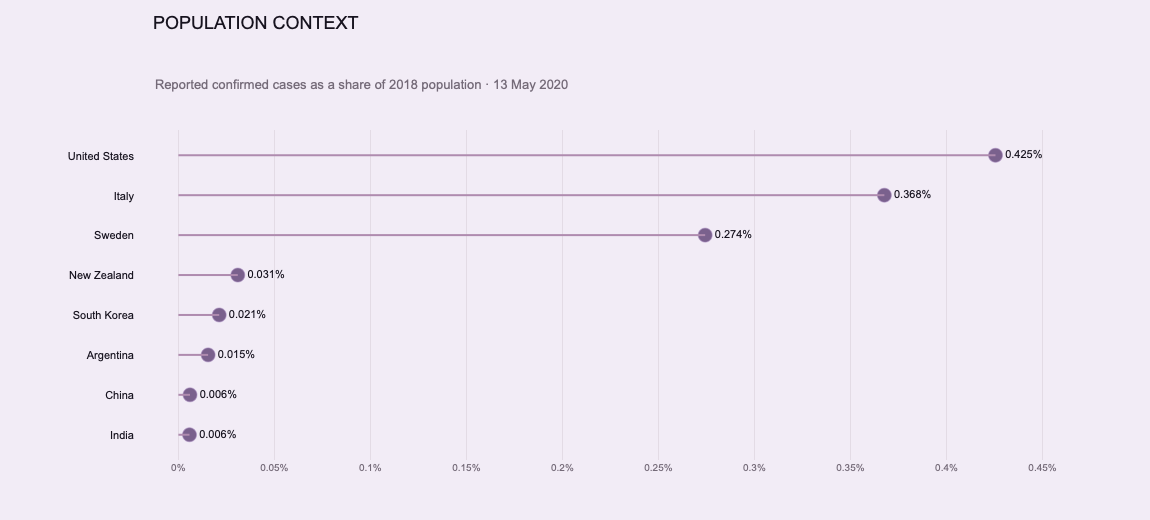

In [19]:
# Population-adjusted comparison — editorial lollipop chart

population_plot = (
    population_comparison
    .sort_values("confirmed_pct_population")
    .copy()
)

population_plot["display_country"] = (
    population_plot["country"]
    .replace(
        {
            "US": "United States",
            "Korea, South": "South Korea",
        }
    )
)

fig = go.Figure()

# Thin stems
for _, row in population_plot.iterrows():
    fig.add_shape(
        type="line",
        x0=0,
        x1=row["confirmed_pct_population"],
        y0=row["display_country"],
        y1=row["display_country"],
        xref="x",
        yref="y",
        line=dict(
            color=PALETTE["archive_purple"],
            width=2,
        ),
    )

# End-point markers
fig.add_trace(
    go.Scatter(
        x=population_plot["confirmed_pct_population"],
        y=population_plot["display_country"],
        mode="markers+text",

      marker=dict(
    size=14,
    color="rgba(93, 62, 115, 0.80)",
    line=dict(
        color="rgba(167, 139, 191, 0.55)",
        width=1
    )
),

        text=population_plot["confirmed_pct_population"].map(
            lambda x: f"{x:.3f}%"
        ),
        textposition="middle right",

        textfont=dict(
            family="Arial",
            size=11,
            color=PALETTE["ink"],
        ),

        customdata=population_plot[
            ["confirmed", "population_2018"]
        ].values,

        hovertemplate=(
            "<b>%{y}</b><br><br>"
            "Confirmed: %{customdata[0]:,.0f}<br>"
            "2018 population: %{customdata[1]:,.0f}<br>"
            "Reported cases / population: %{x:.3f}%"
            "<extra></extra>"
        ),

        showlegend=False,
    )
)


fig.update_layout(
    title=dict(
        text="POPULATION CONTEXT",
        x=0.02,
        xref="paper",
        xanchor="left",
        y=0.97,
        yanchor="top",
        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=520,

    margin=dict(
        l=135,
        r=100,
        t=130,
        b=60,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
)


fig.add_annotation(
    text="Reported confirmed cases as a share of 2018 population · 13 May 2020",
    x=0.02,
    y=1.11,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


fig.update_xaxes(
    title="",
    ticksuffix="%",
    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,
    zeroline=False,
    tickfont=dict(
        size=10,
        color=PALETTE["muted"],
    ),
)


fig.update_yaxes(
    title="",
    showgrid=False,
    tickfont=dict(
        size=11,
        color=PALETTE["ink"],
    ),
)


fig.show()

Adjusting for population changes the comparison substantially: countries with
the largest absolute case totals are not necessarily those with the largest
reported case burden relative to population size.

This comparison remains dependent on differences in testing and reporting
between countries and uses 2018 population figures, consistent with the
historical project.

### COVID-19 progression over time

The original project included an animated bar-chart race showing how the
countries with the highest reported confirmed case counts changed during the
early months of the pandemic.

The visualization was developed by a teammate after it was proposed as an
additional project feature. The implementation was adapted from bar-chart-race
examples by **Pratap Vardhan** and **John Burn-Murdoch**, whose work was also
credited in the original 2020 notebook.

For computational efficiency and consistency with the historical project, the
animation begins on February 25, 2020.

In [20]:
import matplotlib.animation as animation
import matplotlib.ticker as ticker

# Historical date columns in the frozen JHU dataset
non_date_columns = {"state", "country", "lat", "long"}

date_columns = [
    col
    for col in CoV_confirmed.columns
    if col not in non_date_columns
]

parsed_dates = pd.to_datetime(
    date_columns,
    format="%m/%d/%y"
)

animation_dates = [
    col
    for col, date in zip(date_columns, parsed_dates)
    if date >= pd.Timestamp("2020-02-25")
]

# Work from a contiguous copy before aggregating province/state rows
confirmed_base = (
    CoV_confirmed[
        ["country"] + date_columns
    ]
    .copy()
)

confirmed_country = (
    confirmed_base
    .groupby("country", as_index=False)[date_columns]
    .sum()
)

# Countries with the highest totals at the end of the analysis window
animation_countries = (
    confirmed_country
    .nlargest(14, date_columns[-1])["country"]
    .tolist()
)

confirmed_animation = (
    confirmed_country[
        confirmed_country["country"].isin(animation_countries)
    ]
    .melt(
        id_vars="country",
        value_vars=animation_dates,
        var_name="date",
        value_name="confirmed",
    )
)

confirmed_animation["date"] = pd.to_datetime(
    confirmed_animation["date"],
    format="%m/%d/%y"
)

frame_dates = (
    confirmed_animation["date"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Animation period:")
print(frame_dates[0], "to", frame_dates[-1])
print("Frames:", len(frame_dates))

Animation period:
2020-02-25 00:00:00 to 2020-05-13 00:00:00
Frames: 79


In [21]:
display_country_names = {
    "US": "United States",
    "Korea, South": "South Korea",
}

# -------------------------------------------------------------------
# Animated country progression
# Country colors remain stable across frames.
# -------------------------------------------------------------------

ANIMATION_COLORS = [
    "#3F6FA0",  # archival blue
    "#79698F",  # muted violet
    "#F2C14E",  # warm yellow
    "#5C8D78",  # sage green
    "#B46F70",  # dusty rose
    "#6F8898",  # slate blue
    "#C68A5B",  # warm ochre
    "#8F6E91",  # mauve
    "#628D96",  # muted teal
    "#A58C72",  # stone brown
    "#7D9A75",  # soft green
    "#B484A3",  # dusty orchid
    "#727B92",  # blue grey
    "#A47763",  # terracotta
]

country_colors = {
    country: ANIMATION_COLORS[i % len(ANIMATION_COLORS)]
    for i, country in enumerate(animation_countries)
}


# Create the animation figure explicitly
fig, ax = plt.subplots(figsize=(15, 8))

fig.patch.set_facecolor(PALETTE["panel_lilac"])
ax.set_facecolor(PALETTE["panel_lilac"])


# Reserve a permanent header band above the plotting area
fig.subplots_adjust(
    top=0.80,
    bottom=0.08,
    left=0.06,
    right=0.97,
)


# Figure-level title: remains fixed while animation frames change
fig.text(
    0.06,
    0.955,
    "COUNTRIES WITH THE HIGHEST REPORTED CONFIRMED CASES",
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold",
    color=PALETTE["ink"],
)

fig.text(
    0.06,
    0.905,
    "Changing country rankings during the early pandemic · 25 Feb–13 May 2020",
    ha="left",
    va="top",
    fontsize=11,
    color=PALETTE["muted"],
)


def draw_barchart(date):
    ax.clear()
    ax.set_facecolor(PALETTE["panel_lilac"])

    date = pd.Timestamp(date)

    frame = (
        confirmed_animation[
            confirmed_animation["date"].eq(date)
        ]
        .sort_values("confirmed", ascending=True)
        .tail(12)
        .copy()
    )

    # Scale each frame while retaining room for labels
    frame_max = max(frame["confirmed"].max(), 1)

    ax.set_xlim(
        0,
        frame_max * 1.18,
    )

    bars = ax.barh(
        frame["country"],
        frame["confirmed"],
        color=[
            country_colors.get(
                country,
                PALETTE["confirmed"],
            )
            for country in frame["country"]
        ],
        alpha=0.88,
        height=0.70,
    )

    # Write country names directly on the bars
    ax.set_yticks([])

    for bar, country, confirmed in zip(
        bars,
        frame["country"],
        frame["confirmed"],
    ):
        y = bar.get_y() + bar.get_height() / 2

        # Country label
        ax.text(
            frame_max * 0.012,
            y,
            country,
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
            color=PALETTE["ink"],
        )

        # Keep values away from country names when bars are short
        value_x = max(
            confirmed + frame_max * 0.012,
            frame_max * 0.18,
        )

        ax.text(
            value_x,
            y,
            f"{confirmed:,.0f}",
            va="center",
            ha="left",
            fontsize=10,
            color=PALETTE["ink"],
        )

    # Large archival date stamp
    ax.text(
        0.985,
        0.08,
        date.strftime("%d %b %Y").upper(),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=27,
        fontweight="bold",
        color=PALETTE["archive_purple"],
        alpha=0.75,
    )

    # Axis styling
    ax.xaxis.set_major_formatter(
        ticker.StrMethodFormatter("{x:,.0f}")
    )

    ax.xaxis.set_ticks_position("top")

    ax.tick_params(
        axis="x",
        colors=PALETTE["muted"],
        labelsize=9,
        length=0,
        pad=7,
    )

    ax.grid(
        axis="x",
        color=PALETTE["grid"],
        linewidth=0.8,
        alpha=0.8,
    )

    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.margins(y=0.03)


plt.close(fig)

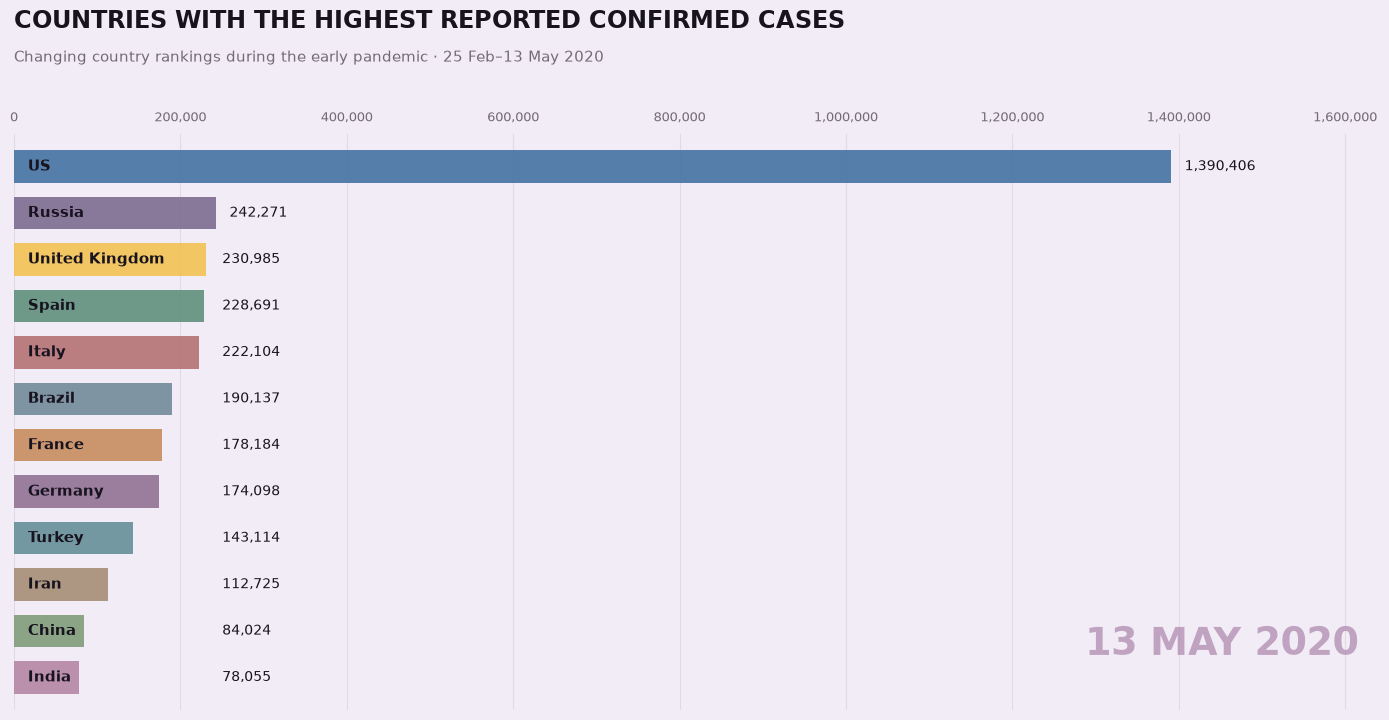

In [22]:
draw_barchart(pd.Timestamp("2020-05-13"))
display(fig)

In [23]:
animation_path = ASSETS_DIR / "covid_country_progression_lilac.gif"

REBUILD_ANIMATION = False

if REBUILD_ANIMATION or not animation_path.exists():
    animator = animation.FuncAnimation(
        fig,
        draw_barchart,
        frames=frame_dates,
        interval=125,
        repeat=False,
    )

    writer = animation.PillowWriter(fps=8)

    animator.save(
        animation_path,
        writer=writer,
        dpi=80,
    )

    print("Animation saved to:", animation_path)
else:
    print("Using existing animation:", animation_path)

Using existing animation: /Users/meghasharma/Documents/Github/Databootcamp_project_2020_covid19_analysis/nyu-covid19-data-analysis/assets/covid_country_progression_lilac.gif


#### Animated country progression

The animation shows how the concentration of reported confirmed cases shifted
across countries between February 25 and May 13, 2020. China dominated the
early ranking, followed by a rapid shift toward European countries and the
United States as reported case counts increased across different regions.

As with the other cross-country comparisons, the animation reflects reported
confirmed cases rather than true infection prevalence.

![Animated progression of reported confirmed COVID-19 cases](../assets/covid_country_progression_lilac.gif)

## 02 · United States

The global analysis showed that the United States had the highest reported
confirmed case total by May 13, 2020. This section looks more closely at how
reported cases were distributed across US states and how national daily case
counts evolved during the historical project period.

State and county-level confirmed-case data are drawn from the same frozen
Johns Hopkins University snapshot used in the global analysis. Daily national
case counts come from the historical CDC-based dataset assembled for the
original project.

In [24]:
CoV_US_Confirmed = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_confirmed_US.csv"
)

CoV_US_deaths = pd.read_csv(
    JHU_DATA_DIR / "time_series_covid19_deaths_US.csv"
)

print("US confirmed:", CoV_US_Confirmed.shape)
print("US deaths:", CoV_US_deaths.shape)
print("Confirmed time series through:", CoV_US_Confirmed.columns[-1])
print("Deaths time series through:", CoV_US_deaths.columns[-1])

US confirmed: (3261, 124)
US deaths: (3261, 125)
Confirmed time series through: 5/13/20
Deaths time series through: 5/13/20


### State-level case burden

The original project ranked states by cumulative confirmed cases. The restored
version performs the same comparison while explicitly aggregating county-level
records to state totals.

In [25]:
# Standardize column names
CoV_US_Confirmed.columns = CoV_US_Confirmed.columns.str.lower()
CoV_US_deaths.columns = CoV_US_deaths.columns.str.lower()

CoV_US_Confirmed = CoV_US_Confirmed.rename(
    columns={"long_": "long"}
)

CoV_US_deaths = CoV_US_deaths.rename(
    columns={"long_": "long"}
)

us_snapshot_date = "5/13/20"

state_confirmed = (
    CoV_US_Confirmed
    .groupby("province_state", as_index=False)[us_snapshot_date]
    .sum()
    .rename(columns={us_snapshot_date: "confirmed"})
)

state_deaths = (
    CoV_US_deaths
    .groupby("province_state", as_index=False)[us_snapshot_date]
    .sum()
    .rename(columns={us_snapshot_date: "deaths"})
)

state_summary = (
    state_confirmed
    .merge(
        state_deaths,
        on="province_state",
        how="left",
        validate="one_to_one",
    )
    .sort_values("confirmed", ascending=False)
)

state_summary.head(10)

,province_state,confirmed,deaths
36,New York,340661,27477
34,New Jersey,141560,9714
17,Illinois,84694,3792
25,Massachusetts,80497,5315
5,California,72798,2957
43,Pennsylvania,62101,4094
26,Michigan,48391,4714
49,Texas,43020,1172
11,Florida,42402,1827
12,Georgia,35427,1517


In [26]:
assert CoV_US_Confirmed.columns[-1] == "5/13/20"
assert CoV_US_deaths.columns[-1] == "5/13/20"

print("US historical snapshot validated.")

US historical snapshot validated.


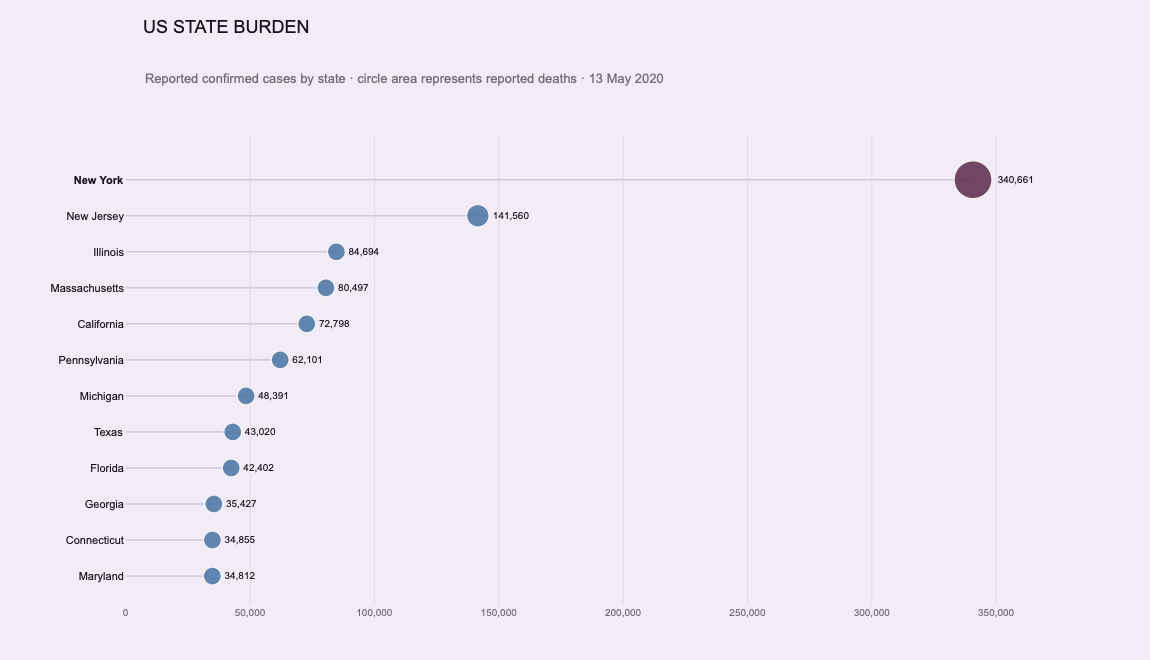

In [27]:
# -------------------------------------------------------------------
# US state burden profile
# Position = reported confirmed cases
# Bubble area = reported deaths
# Historical snapshot: 13 May 2020
# -------------------------------------------------------------------

top_states = (
    state_summary
    .head(12)
    .sort_values("confirmed")
    .copy()
)

# Bubble area is proportional to reported deaths.
max_deaths = max(top_states["deaths"].max(), 1)

size_ref = (
    2.0 * max_deaths
    / (38 ** 2)
)

# Highlight New York because it dominated the historical snapshot.
point_colors = [
    PALETTE["deep_plum"]
    if state == "New York"
    else PALETTE["confirmed"]
    for state in top_states["province_state"]
]

# Slightly emphasize New York in the state labels as well.
state_labels = [
    f"<b>{state}</b>"
    if state == "New York"
    else state
    for state in top_states["province_state"]
]


fig = go.Figure()


# Fine horizontal guide lines create a ranked "signal field".
for _, row in top_states.iterrows():
    fig.add_shape(
        type="line",
        x0=0,
        x1=row["confirmed"],
        y0=row["province_state"],
        y1=row["province_state"],
        xref="x",
        yref="y",
        line=dict(
            color="rgba(167, 139, 191, 0.42)",
            width=1.5,
        ),
        layer="below",
    )


# State markers
fig.add_trace(
    go.Scatter(
        x=top_states["confirmed"],
        y=top_states["province_state"],
        mode="markers+text",

        marker=dict(
            size=top_states["deaths"],
            sizemode="area",
            sizeref=size_ref,
            sizemin=9,
            color=point_colors,
            opacity=0.82,
            line=dict(
                color=PALETTE["paper"],
                width=1.4,
            ),
        ),

        text=top_states["confirmed"].map(
            lambda x: f"{x:,.0f}"
        ),

        textposition="middle right",

        textfont=dict(
            family="Arial",
            size=10,
            color=PALETTE["ink"],
        ),

        customdata=top_states[
            ["deaths"]
        ].values,

        hovertemplate=(
            "<b>%{y}</b><br><br>"
            "Confirmed cases: %{x:,.0f}<br>"
            "Reported deaths: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),

        showlegend=False,
    )
)


fig.update_layout(
    title=dict(
        text="US STATE BURDEN",
        x=0.02,
        xref="paper",
        xanchor="left",
        y=0.97,
        yanchor="top",
        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=660,

    margin=dict(
        l=125,
        r=110,
        t=135,
        b=55,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
)


# Editorial subtitle
fig.add_annotation(
    text=(
        "Reported confirmed cases by state · "
        "circle area represents reported deaths · "
        "13 May 2020"
    ),
    x=0.02,
    y=1.10,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


fig.update_xaxes(
    title="",
    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,
    zeroline=False,
    tickformat=",",
    tickfont=dict(
        size=10,
        color=PALETTE["muted"],
    ),
)


fig.update_yaxes(
    title="",
    showgrid=False,
    tickmode="array",
    tickvals=top_states["province_state"],
    ticktext=state_labels,
    tickfont=dict(
        size=11,
        color=PALETTE["ink"],
    ),
)


fig.show()

Reported case burden was highly concentrated across a relatively small number
of states by mid-May 2020, with New York standing far above the rest of the
country in cumulative confirmed cases.

These totals reflect reported cases rather than population-adjusted infection
rates and are influenced by differences in testing and reporting across states.

### Geographic distribution

County-level coordinates provide additional context on where reported confirmed
cases were concentrated across the United States.

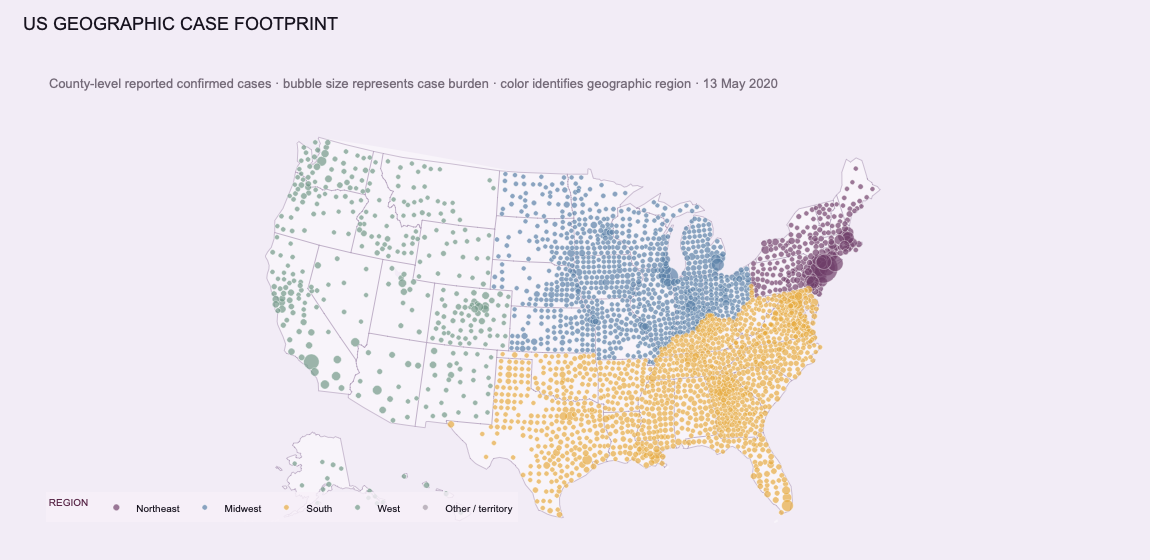

In [28]:
us_map_data = (
    CoV_US_Confirmed[
        ["province_state", "admin2", "lat", "long", us_snapshot_date]
    ]
    .rename(columns={us_snapshot_date: "confirmed"})
    .dropna(subset=["lat", "long"])
    .copy()
)

us_map_data = us_map_data[
    us_map_data["confirmed"] > 0
]

# -------------------------------------------------------------------
# US geographic case footprint
# Bubble size = reported confirmed cases
# Bubble color = US geographic region
# Historical snapshot: 13 May 2020
# -------------------------------------------------------------------

us_map_plot = us_map_data.copy()


# Geographic regions used only to add spatial context to the map
NORTHEAST = {
    "Maine", "New Hampshire", "Vermont", "Massachusetts",
    "Rhode Island", "Connecticut", "New York",
    "New Jersey", "Pennsylvania",
}

MIDWEST = {
    "Ohio", "Indiana", "Illinois", "Michigan", "Wisconsin",
    "Iowa", "Kansas", "Minnesota", "Missouri",
    "Nebraska", "North Dakota", "South Dakota",
}

SOUTH = {
    "Delaware", "Florida", "Georgia", "Maryland",
    "North Carolina", "South Carolina", "Virginia",
    "District of Columbia", "West Virginia",
    "Alabama", "Kentucky", "Mississippi", "Tennessee",
    "Arkansas", "Louisiana", "Oklahoma", "Texas",
}

WEST = {
    "Arizona", "Colorado", "Idaho", "Montana",
    "Nevada", "New Mexico", "Utah", "Wyoming",
    "Alaska", "California", "Hawaii",
    "Oregon", "Washington",
}


def assign_us_region(state):
    if state in NORTHEAST:
        return "Northeast"

    if state in MIDWEST:
        return "Midwest"

    if state in SOUTH:
        return "South"

    if state in WEST:
        return "West"

    return "Other / territory"


us_map_plot["region"] = (
    us_map_plot["province_state"]
    .map(assign_us_region)
)


# Square-root scaling preserves relative ordering while preventing
# the largest counties from dominating the entire visual.
sqrt_cases = np.sqrt(us_map_plot["confirmed"])

us_map_plot["marker_size"] = (
    5
    + 25
    * (
        (sqrt_cases - sqrt_cases.min())
        / (sqrt_cases.max() - sqrt_cases.min())
    )
)


# Regional colors follow the broader notebook palette
REGION_COLORS = {
    "Northeast": "#6F3E68",          # deep plum
    "Midwest": "#557EA5",            # archival blue
    "South": "#E6A93D",              # warm gold
    "West": "#6E9785",               # muted sage
    "Other / territory": "#A49AA5",  # soft grey
}


fig = go.Figure()


# One trace per region gives us a meaningful color legend
for region in [
    "Northeast",
    "Midwest",
    "South",
    "West",
    "Other / territory",
]:

    region_data = us_map_plot[
        us_map_plot["region"].eq(region)
    ]

    if region_data.empty:
        continue

    fig.add_trace(
        go.Scattergeo(
            lat=region_data["lat"],
            lon=region_data["long"],

            mode="markers",

            name=region,

            marker=dict(
                size=region_data["marker_size"],
                color=REGION_COLORS[region],
                opacity=0.68,

                line=dict(
                    color="rgba(255,255,255,0.78)",
                    width=0.6,
                ),
            ),

            customdata=region_data[
                [
                    "admin2",
                    "province_state",
                    "region",
                    "confirmed",
                ]
            ].values,

            hovertemplate=(
                "<b>%{customdata[0]}, %{customdata[1]}</b><br>"
                "%{customdata[2]}<br><br>"
                "Reported confirmed cases: "
                "%{customdata[3]:,.0f}"
                "<extra></extra>"
            ),
        )
    )


fig.update_geos(
    scope="usa",

    bgcolor=PALETTE["panel_lilac"],

    showland=True,
    landcolor="#F8F4FA",

    showlakes=True,
    lakecolor=PALETTE["panel_lilac"],

    showcountries=False,

    showsubunits=True,
    subunitcolor="#B9A8C2",
    subunitwidth=0.7,

    coastlinecolor="#B9A8C2",

    projection_type="albers usa",
)


fig.update_layout(
    title=dict(
        text="US GEOGRAPHIC CASE FOOTPRINT",
        x=0.02,
        xanchor="left",
        y=0.97,
        yanchor="top",

        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],

    height=560,

    margin=dict(
        l=25,
        r=30,
        t=125,
        b=30,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),

    legend=dict(
        title=dict(
            text="REGION",
            font=dict(
                size=10,
                color=PALETTE["deep_plum"],
            ),
        ),

        orientation="h",

        x=0.02,
        y=0.02,

        xanchor="left",
        yanchor="bottom",

        bgcolor="rgba(247,240,249,0.80)",

        font=dict(
            size=10,
            color=PALETTE["ink"],
        ),
    ),
)


fig.add_annotation(
    text=(
        "County-level reported confirmed cases · "
        "bubble size represents case burden · "
        "color identifies geographic region · "
        "13 May 2020"
    ),

    x=0.02,
    y=1.08,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


fig.show()

### Daily reported cases

State-level cumulative totals show where reported cases were concentrated, while
daily national case counts provide a view of how reported cases evolved
through the early months of the US outbreak.

The original project assembled this historical series from CDC figures available
during Spring 2020. The restored analysis uses the preserved project dataset
rather than reconstructing the series from current sources.

In [29]:
daily_us = pd.read_csv(
    RAW_DATA_DIR / "daily_new_covid_usa.csv"
)

print("Shape:", daily_us.shape)
print("Columns:", daily_us.columns.tolist())

display(daily_us.head())
display(daily_us.tail())

Shape: (77, 2)
Columns: ['Date', 'Cases']


,Date,Cases
0,2/25/20,0
1,2/26/20,0
2,2/27/20,1
3,2/28/20,0
4,2/29/20,8


,Date,Cases
72,5/7/20,28974
73,5/8/20,25996
74,5/9/20,26660
75,5/10/20,23792
76,5/11/20,18106


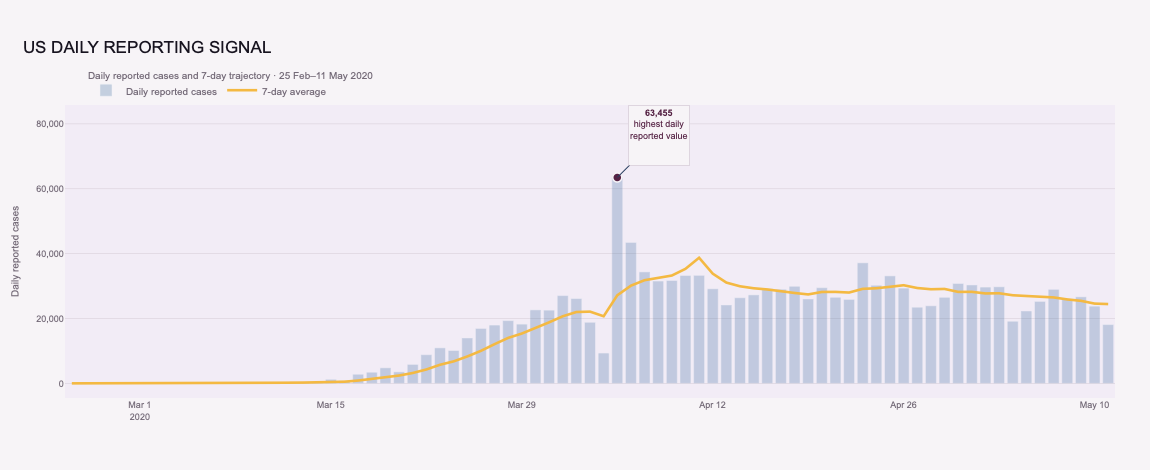

In [30]:
daily_us["Date"] = pd.to_datetime(
    daily_us["Date"],
    format="%m/%d/%y"
)

daily_us = (
    daily_us
    .sort_values("Date")
    .reset_index(drop=True)
)

# Seven-day average added only to make the daily trend easier to read.
daily_us["7_day_average"] = (
    daily_us["Cases"]
    .rolling(window=7, min_periods=1)
    .mean()
)

peak_idx = daily_us["Cases"].idxmax()
peak_date = daily_us.loc[peak_idx, "Date"]
peak_cases = daily_us.loc[peak_idx, "Cases"]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=daily_us["Date"],
        y=daily_us["Cases"],
        name="Daily reported cases",
        marker_color=PALETTE["confirmed"],
        opacity=0.28,
        hovertemplate=(
            "<b>%{x|%d %b %Y}</b><br>"
            "Daily reported cases: %{y:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter(
        x=daily_us["Date"],
        y=daily_us["7_day_average"],
        mode="lines",
        name="7-day average",
        line=dict(
            color=PALETTE["gold"],
            width=2.6,
        ),
        hovertemplate=(
            "<b>%{x|%d %b %Y}</b><br>"
            "7-day average: %{y:,.0f}"
            "<extra></extra>"
        ),
    )
)

# Mark the largest single reported daily value without treating it
# as an epidemiological peak.
fig.add_trace(
    go.Scatter(
        x=[peak_date],
        y=[peak_cases],
        mode="markers",
        marker=dict(
            size=9,
            color=PALETTE["deep_plum"],
            line=dict(
                color=PALETTE["paper"],
                width=1.5,
            ),
        ),
        showlegend=False,
        hovertemplate=(
            "<b>%{x|%d %b %Y}</b><br>"
            "Highest daily reported value: %{y:,.0f}"
            "<extra></extra>"
        ),
    )
)

fig.add_annotation(
    x=peak_date,
    y=peak_cases,
    text=(
        f"<b>{peak_cases:,.0f}</b><br>"
        "highest daily<br>reported value"
    ),
    showarrow=True,
    arrowhead=0,
    ax=42,
    ay=-42,
    bgcolor=PALETTE["paper"],
    bordercolor=PALETTE["grid"],
    borderwidth=1,
    font=dict(
        family="Arial",
        size=9,
        color=PALETTE["deep_plum"],
    ),
)

fig.update_layout(
    title=dict(
        text="US DAILY REPORTING SIGNAL",
        x=0.02,
        xanchor="left",
        font=dict(
            family="Arial",
            size=17,
            color=PALETTE["ink"],
        ),
    ),
    paper_bgcolor=PALETTE["paper"],
    plot_bgcolor=PALETTE["panel_lilac"],
    height=470,
    margin=dict(l=65, r=35, t=105, b=60),
    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
    xaxis_title="",
    yaxis_title="Daily reported cases",
    legend=dict(
        orientation="h",
        y=1.10,
        x=0.02,
        font=dict(
            size=10,
            color=PALETTE["muted"],
        ),
    ),
)

fig.add_annotation(
    text=(
        "Daily reported cases and 7-day trajectory · "
        "25 Feb–11 May 2020"
    ),
    x=0.02,
    y=1.08,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Arial",
        size=10,
        color=PALETTE["muted"],
    ),
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
)

fig.update_yaxes(
    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,
    zeroline=False,
    tickformat=",",
    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
    title_font=dict(
        size=10,
        color=PALETTE["muted"],
    ),
)

fig.show()

Daily reported case counts increased sharply during March and remained elevated
through April and early May 2020. Day-to-day reporting was volatile, so the
seven-day average is included to make the broader trajectory easier to see.

The series should be interpreted as reported case activity rather than the true
number of infections, particularly given changes in testing availability and
reporting practices during the early US outbreak.

## 03 · New York City

New York City was one of the earliest and most heavily affected US population
centers during the first wave of COVID-19.

This section examines three dimensions of the city's reported outbreak during
the historical project period:

- daily reported cases, hospitalizations, and deaths;
- differences across age groups;
- differences by sex.

The analysis uses locally preserved snapshots from the New York City Department
of Health and Mental Hygiene COVID-19 repository, pinned to the historical
repository state used by the original project.

### Historical NYC data

In [31]:
NYC_DATA_DIR = RAW_DATA_DIR / "nyc"

nyc_daily = pd.read_csv(
    NYC_DATA_DIR / "case-hosp-death.csv"
)

nyc_age = pd.read_csv(
    NYC_DATA_DIR / "by-age.csv"
)

nyc_sex = pd.read_csv(
    NYC_DATA_DIR / "by-sex.csv"
)

print("Daily data:", nyc_daily.shape)
print("Daily columns:", nyc_daily.columns.tolist())

print()
print("Age data:", nyc_age.shape)
print("Age columns:", nyc_age.columns.tolist())

print()
print("Sex data:", nyc_sex.shape)
print("Sex columns:", nyc_sex.columns.tolist())

Daily data: (73, 4)
Daily columns: ['DATE_OF_INTEREST', 'CASE_COUNT', 'HOSPITALIZED_COUNT', 'DEATH_COUNT']

Age data: (6, 4)
Age columns: ['AGE_GROUP', 'COVID_CASE_RATE', 'HOSPITALIZED_CASE_RATE', 'DEATH_RATE']

Sex data: (3, 4)
Sex columns: ['SEX_GROUP', 'COVID_CASE_RATE', 'HOSPITALIZED_CASE_RATE', 'DEATH_RATE']


### Daily outbreak patterns

Daily reported cases, hospitalizations, and deaths provide complementary views
of the first major COVID-19 wave in New York City.

Because daily reporting can be volatile and recent observations may be affected
by reporting delays, seven-day averages are included to emphasize the broader
trajectory rather than individual daily fluctuations.

In [32]:
nyc_daily["DATE_OF_INTEREST"] = pd.to_datetime(
    nyc_daily["DATE_OF_INTEREST"],
    format="%m/%d/%y"
)

nyc_daily = (
    nyc_daily
    .sort_values("DATE_OF_INTEREST")
    .reset_index(drop=True)
)

for metric in [
    "CASE_COUNT",
    "HOSPITALIZED_COUNT",
    "DEATH_COUNT",
]:
    nyc_daily[f"{metric}_7DAY"] = (
        nyc_daily[metric]
        .rolling(window=7, min_periods=1)
        .mean()
    )

assert nyc_daily["DATE_OF_INTEREST"].iloc[-1] == pd.Timestamp("2020-05-11")
assert nyc_daily.iloc[-1]["CASE_COUNT"] == 26
assert nyc_daily.iloc[-1]["HOSPITALIZED_COUNT"] == 0
assert nyc_daily.iloc[-1]["DEATH_COUNT"] == 3

print("Historical NYC daily series validated.")

Historical NYC daily series validated.


Reported cases, hospitalizations, and deaths rose sharply during the first NYC
wave and later declined within the historical series.

The timing and magnitude of those changes differ across the three measures.
Recent daily observations in the dataset should be interpreted cautiously
because reporting delays can make the latest values appear artificially low.

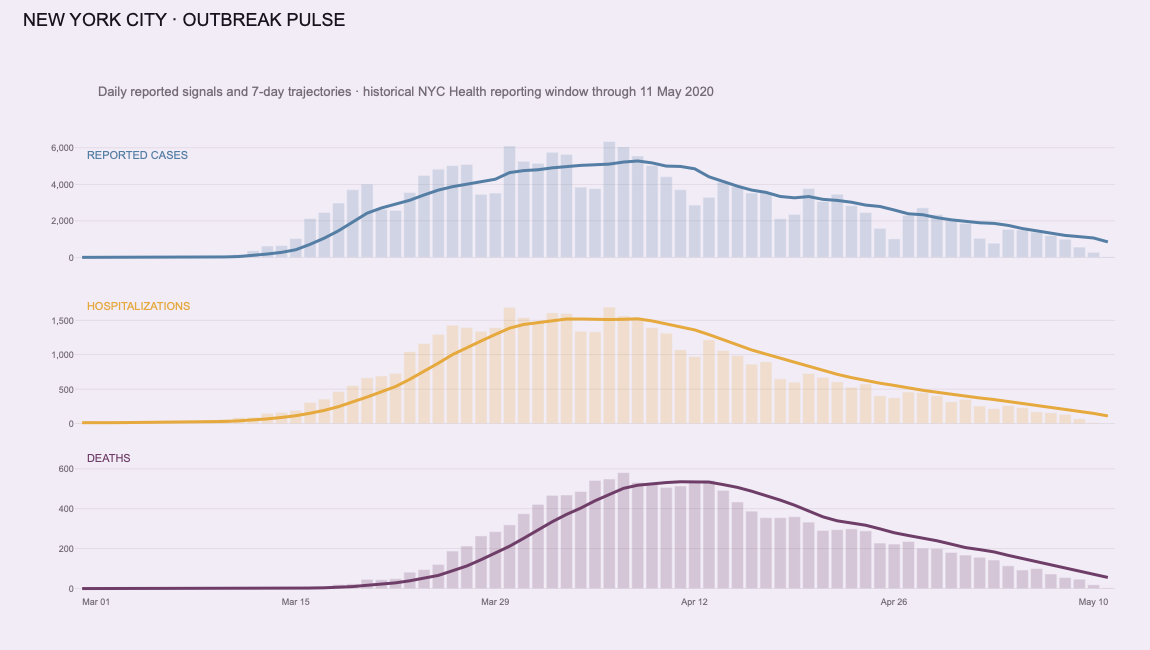

In [33]:
# -------------------------------------------------------------------
# NYC outbreak pulse
# Three aligned signals preserve their different scales while showing
# how reported cases, hospitalizations, and deaths evolved over time.
# -------------------------------------------------------------------

nyc_signals = [
    {
        "metric": "CASE_COUNT",
        "average": "CASE_COUNT_7DAY",
        "label": "REPORTED CASES",
        "color": "#557EA5",
    },
    {
        "metric": "HOSPITALIZED_COUNT",
        "average": "HOSPITALIZED_COUNT_7DAY",
        "label": "HOSPITALIZATIONS",
        "color": "#E6A93D",
    },
    {
        "metric": "DEATH_COUNT",
        "average": "DEATH_COUNT_7DAY",
        "label": "DEATHS",
        "color": "#6F3E68",
    },
]


fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
)


for row, signal in enumerate(nyc_signals, start=1):

    color = signal["color"]

    # Daily reported values
    fig.add_trace(
        go.Bar(
            x=nyc_daily["DATE_OF_INTEREST"],
            y=nyc_daily[signal["metric"]],

            marker=dict(
                color=color,
                opacity=0.22,
            ),

            hovertemplate=(
                "<b>%{x|%d %b %Y}</b><br>"
                "Daily reported value: %{y:,.0f}"
                "<extra></extra>"
            ),

            showlegend=False,
        ),
        row=row,
        col=1,
    )

    # Seven-day trajectory
    fig.add_trace(
        go.Scatter(
            x=nyc_daily["DATE_OF_INTEREST"],
            y=nyc_daily[signal["average"]],

            mode="lines",

            line=dict(
                color=color,
                width=3,
            ),

            hovertemplate=(
                "<b>%{x|%d %b %Y}</b><br>"
                "7-day average: %{y:,.0f}"
                "<extra></extra>"
            ),

            showlegend=False,
        ),
        row=row,
        col=1,
    )


# Editorial panel labels
for y, signal in zip(
    [0.94, 0.61, 0.28],
    nyc_signals,
):
    fig.add_annotation(
        text=signal["label"],

        x=0.01,
        y=y,

        xref="paper",
        yref="paper",

        xanchor="left",
        yanchor="bottom",

        showarrow=False,

        font=dict(
            family="Arial",
            size=11,
            color=signal["color"],
        ),
    )


fig.update_layout(
    title=dict(
        text="NEW YORK CITY · OUTBREAK PULSE",
        x=0.02,
        xanchor="left",
        y=0.98,
        yanchor="top",

        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=650,

    margin=dict(
        l=75,
        r=35,
        t=135,
        b=55,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),

    bargap=0.16,
)


fig.add_annotation(
    text=(
        "Daily reported signals and 7-day trajectories · "
        "historical NYC Health reporting window through 11 May 2020"
    ),

    x=0.02,
    y=1.075,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


fig.update_xaxes(
    showgrid=False,
    zeroline=False,

    tickformat="%b %d",

    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
)


fig.update_yaxes(
    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,

    zeroline=False,

    tickformat=",",

    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
)


fig.show()

### Patterns by age

The historical NYC Health snapshot also reported COVID-19 case,
hospitalization, and death rates across age groups.

The citywide aggregate is excluded from the comparison below so that the age
groups can be compared directly.

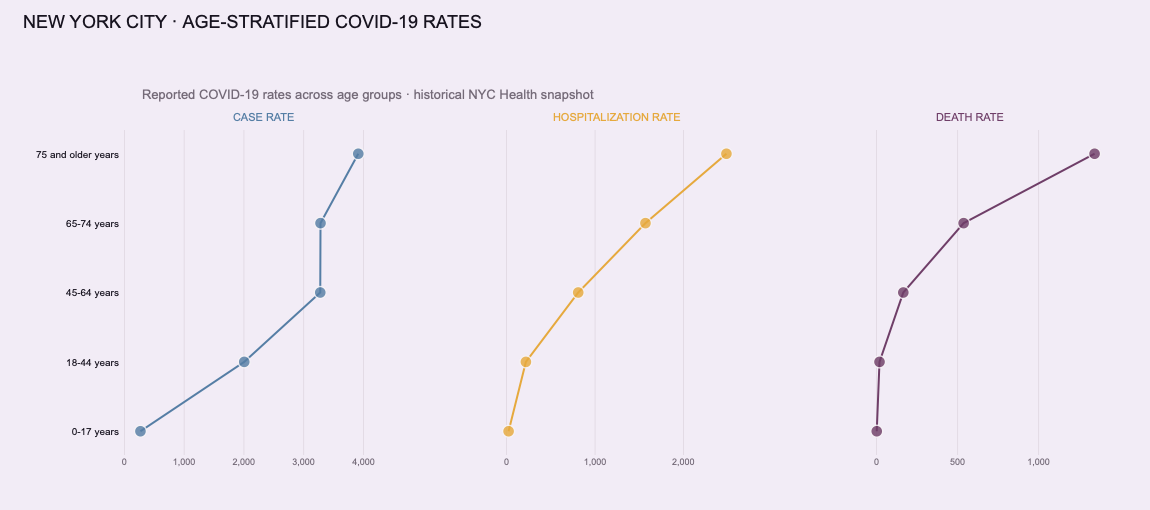

In [34]:
nyc_age_plot = (
    nyc_age[
        nyc_age["AGE_GROUP"] != "Citywide total"
    ]
    .copy()
)

# -------------------------------------------------------------------
# NYC age severity profile
# Three rate measures shown with a common age ordering.
# -------------------------------------------------------------------

age_order = [
    "0-17 years",
    "18-44 years",
    "45-64 years",
    "65-74 years",
    "75 and older years",
]

age_plot = (
    nyc_age_plot
    .set_index("AGE_GROUP")
    .reindex(age_order)
    .reset_index()
)

age_metrics = [
    {
        "metric": "COVID_CASE_RATE",
        "label": "CASE RATE",
        "color": "#557EA5",
    },
    {
        "metric": "HOSPITALIZED_CASE_RATE",
        "label": "HOSPITALIZATION RATE",
        "color": "#E6A93D",
    },
    {
        "metric": "DEATH_RATE",
        "label": "DEATH RATE",
        "color": "#6F3E68",
    },
]

fig = make_subplots(
    rows=1,
    cols=3,
    horizontal_spacing=0.11,
)


for col, signal in enumerate(age_metrics, start=1):

    metric = signal["metric"]
    color = signal["color"]

    fig.add_trace(
        go.Scatter(
            x=age_plot[metric],
            y=age_plot["AGE_GROUP"],

            mode="lines+markers",

            line=dict(
                color=color,
                width=2,
            ),

            marker=dict(
                size=12,
                color=color,
                opacity=0.82,
                line=dict(
                    color=PALETTE["paper"],
                    width=1.4,
                ),
            ),

            customdata=age_plot[
                ["AGE_GROUP"]
            ].values,

            hovertemplate=(
                "<b>%{customdata[0]}</b><br>"
                "Reported rate: %{x:,.2f}"
                "<extra></extra>"
            ),

            showlegend=False,
        ),
        row=1,
        col=col,
    )


fig.update_layout(
    title=dict(
        text="NEW YORK CITY · AGE-STRATIFIED COVID-19 RATES",
        x=0.02,
        xanchor="left",
        y=0.97,
        yanchor="top",

        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=510,

    margin=dict(
        l=120,
        r=35,
        t=130,
        b=55,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
)


fig.add_annotation(
    text=(
        "Reported COVID-19 rates across age groups · "
        "historical NYC Health snapshot"
    ),

    x=0.02,
    y=1.08,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


# Panel headings
for x, signal in zip(
    [0.145, 0.50, 0.855],
    age_metrics,
):

    fig.add_annotation(
        text=signal["label"],

        x=x,
        y=1.015,

        xref="paper",
        yref="paper",

        xanchor="center",
        yanchor="bottom",

        showarrow=False,

        font=dict(
            family="Arial",
            size=11,
            color=signal["color"],
        ),
    )


fig.update_xaxes(
    title="",

    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,

    zeroline=False,

    tickformat=",",

    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
)


fig.update_yaxes(
    title="",

    showgrid=False,

    tickfont=dict(
        size=10,
        color=PALETTE["ink"],
    ),
)


# Only the first panel needs the age labels
fig.update_yaxes(
    showticklabels=False,
    row=1,
    col=2,
)

fig.update_yaxes(
    showticklabels=False,
    row=1,
    col=3,
)


fig.show()

The historical age profile shows a pronounced increase in severe-outcome rates
with age. The oldest groups had substantially higher hospitalization and death
rates than younger groups within the May 2020 NYC Health snapshot.

These figures describe the reported historical data and should not be interpreted
as estimates of individual risk independent of other factors.

### Patterns by sex

The same historical NYC Health snapshot reported case, hospitalization, and
death rates by sex. The citywide aggregate is again excluded so the two reported
groups can be compared directly.

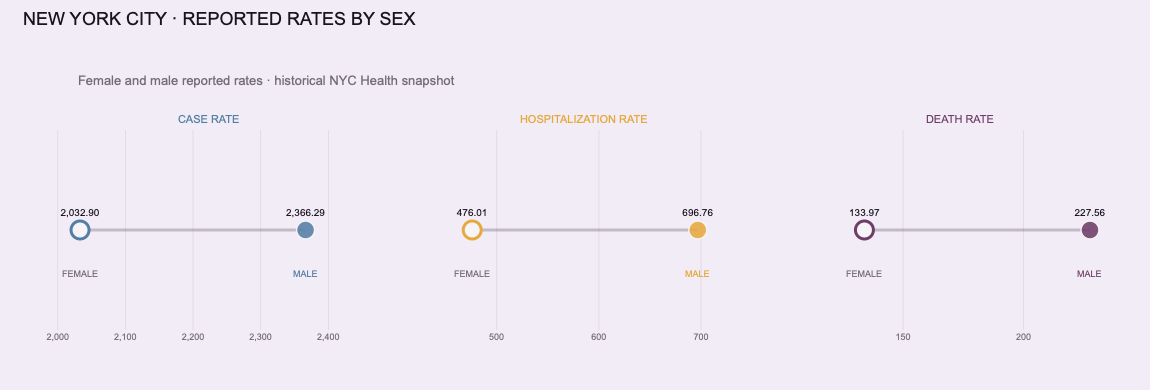

In [35]:
nyc_sex_plot = (
    nyc_sex[
        nyc_sex["SEX_GROUP"] != "Citywide total"
    ]
    .copy()
)

# -------------------------------------------------------------------
# NYC sex comparison
# Paired points emphasize the gap between the two reported groups
# without using three separate conventional bar charts.
# -------------------------------------------------------------------

sex_metrics = [
    {
        "metric": "COVID_CASE_RATE",
        "label": "CASE RATE",
        "color": "#557EA5",
    },
    {
        "metric": "HOSPITALIZED_CASE_RATE",
        "label": "HOSPITALIZATION RATE",
        "color": "#E6A93D",
    },
    {
        "metric": "DEATH_RATE",
        "label": "DEATH RATE",
        "color": "#6F3E68",
    },
]


fig = make_subplots(
    rows=1,
    cols=3,
    horizontal_spacing=0.11,
)


for col, signal in enumerate(sex_metrics, start=1):

    metric = signal["metric"]
    color = signal["color"]

    female_value = (
        nyc_sex_plot
        .loc[
            nyc_sex_plot["SEX_GROUP"].eq("Female"),
            metric,
        ]
        .iloc[0]
    )

    male_value = (
        nyc_sex_plot
        .loc[
            nyc_sex_plot["SEX_GROUP"].eq("Male"),
            metric,
        ]
        .iloc[0]
    )

    # Connector
    fig.add_trace(
        go.Scatter(
            x=[female_value, male_value],
            y=[0, 0],

            mode="lines",

            line=dict(
                color="rgba(116,106,120,0.38)",
                width=3,
            ),

            hoverinfo="skip",
            showlegend=False,
        ),
        row=1,
        col=col,
    )

    # Female point
    fig.add_trace(
        go.Scatter(
            x=[female_value],
            y=[0],

            mode="markers+text",

            marker=dict(
                size=18,
                color=PALETTE["paper"],
                line=dict(
                    color=color,
                    width=3,
                ),
            ),

            text=[f"{female_value:,.2f}"],
            textposition="top center",

            textfont=dict(
                size=10,
                color=PALETTE["ink"],
            ),

            hovertemplate=(
                "<b>Female</b><br>"
                f"{signal['label'].title()}: "
                "%{x:,.2f}"
                "<extra></extra>"
            ),

            showlegend=False,
        ),
        row=1,
        col=col,
    )

    # Male point
    fig.add_trace(
        go.Scatter(
            x=[male_value],
            y=[0],

            mode="markers+text",

            marker=dict(
                size=18,
                color=color,
                opacity=0.88,
                line=dict(
                    color=PALETTE["paper"],
                    width=1.5,
                ),
            ),

            text=[f"{male_value:,.2f}"],
            textposition="top center",

            textfont=dict(
                size=10,
                color=PALETTE["ink"],
            ),

            hovertemplate=(
                "<b>Male</b><br>"
                f"{signal['label'].title()}: "
                "%{x:,.2f}"
                "<extra></extra>"
            ),

            showlegend=False,
        ),
        row=1,
        col=col,
    )

    # Direct group labels underneath
    fig.add_annotation(
        x=female_value,
        y=-0.12,

        text="FEMALE",

        xref=f"x{col}" if col > 1 else "x",
        yref=f"y{col}" if col > 1 else "y",

        showarrow=False,

        font=dict(
            family="Arial",
            size=9,
            color=PALETTE["muted"],
        ),
    )

    fig.add_annotation(
        x=male_value,
        y=-0.12,

        text="MALE",

        xref=f"x{col}" if col > 1 else "x",
        yref=f"y{col}" if col > 1 else "y",

        showarrow=False,

        font=dict(
            family="Arial",
            size=9,
            color=color,
        ),
    )


fig.update_layout(
    title=dict(
        text="NEW YORK CITY · REPORTED RATES BY SEX",
        x=0.02,
        xanchor="left",
        y=0.97,
        yanchor="top",

        font=dict(
            family="Arial",
            size=18,
            color=PALETTE["ink"],
        ),
    ),

    paper_bgcolor=PALETTE["panel_lilac"],
    plot_bgcolor=PALETTE["panel_lilac"],

    height=390,

    margin=dict(
        l=55,
        r=35,
        t=130,
        b=60,
    ),

    font=dict(
        family="Arial",
        color=PALETTE["ink"],
    ),
)


fig.add_annotation(
    text=(
        "Female and male reported rates · "
        "historical NYC Health snapshot"
    ),

    x=0.02,
    y=1.2,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=13,
        color=PALETTE["muted"],
    ),
)


# Panel headings
for x, signal in zip(
    [0.145, 0.50, 0.855],
    sex_metrics,
):

    fig.add_annotation(
        text=signal["label"],

        x=x,
        y=1.015,

        xref="paper",
        yref="paper",

        xanchor="center",
        yanchor="bottom",

        showarrow=False,

        font=dict(
            family="Arial",
            size=11,
            color=signal["color"],
        ),
    )


fig.update_xaxes(
    title="",

    showgrid=True,
    gridcolor=PALETTE["grid"],
    gridwidth=0.7,

    zeroline=False,

    tickformat=",",

    tickfont=dict(
        size=9,
        color=PALETTE["muted"],
    ),
)


fig.update_yaxes(
    visible=False,
    range=[-0.28, 0.28],
)


fig.show()

In this historical NYC snapshot, the reported case, hospitalization, and death
rates were all higher for males than for females, with the difference becoming
more pronounced for hospitalization and death rates.

As with the age comparison, these descriptive rates do not establish why the
differences occurred.

## 04 · State-Level Testing Regression

The original project used exploratory ordinary least squares (OLS) regression
to examine how reported state-level COVID-19 testing volumes were associated
with selected state characteristics.

The dependent variable was **Tested**, representing the number of people tested
for COVID-19 in each state. Five predictors were examined individually:

- **Physicians** — number of physicians in the state
- **Health_Spending** — annual health spending
- **Income** — median income
- **Pollution** — pollution index
- **Population** — state population

The regression work was developed by a teammate as part of the original
three-person project.

> **Restoration note:** The recovered archive contains the original composite
> `COVID19_state metrics.csv` file, but its source provenance is not documented
> clearly enough to redistribute it confidently. The restored notebook therefore
> reports the regression results preserved in the executed 2020 project rather
> than presenting the analysis as a newly reproduced model fit.

### Simple regression results

Each predictor was first examined separately using a simple linear regression.

The comparison below summarizes the original Spring 2020 model outputs.

In [36]:
simple_regression_results = pd.DataFrame(
    {
        "Predictor": [
            "Physicians",
            "Health spending",
            "Income",
            "Pollution",
            "Population",
        ],
        "R_squared": [
            0.603,
            0.004,
            0.148,
            0.050,
            0.397,
        ],
        "model_p_value": [
            2.19e-11,
            0.675,
            0.00537,
            0.114,
            7.17e-07,
        ],
    }
)

simple_regression_results["Statistically significant"] = (
    simple_regression_results["model_p_value"] < 0.05
)

simple_regression_results

,Predictor,R_squared,model_p_value,Statistically significant
0,Physicians,0.603,2.190000e-11,True
1,Health spending,0.004,6.750000e-01,False
2,Income,0.148,5.370000e-03,True
3,Pollution,0.050,1.140000e-01,False
4,Population,0.397,7.170000e-07,True


In [37]:
from IPython.display import HTML, display


# -------------------------------------------------------------------
# Simple OLS evidence board
# Preserves the original Spring 2020 model results while presenting
# model fit and statistical significance without implying causality.
# -------------------------------------------------------------------

model_board = (
    simple_regression_results
    .sort_values("R_squared", ascending=False)
    .copy()
)


rows_html = ""

for _, row in model_board.iterrows():

    significant = bool(row["Statistically significant"])

    signal_color = (
        PALETTE["deep_plum"]
        if significant
        else "#9B949D"
    )

    signal_fill = (
        "#EFE4F0"
        if significant
        else "#EEECEF"
    )

    status_text = (
        "p < 0.05"
        if significant
        else "p ≥ 0.05"
    )

    r2_width = row["R_squared"] * 100

    p_value_text = (
        f"{row['model_p_value']:.2e}"
        if row["model_p_value"] < 0.001
        else f"{row['model_p_value']:.3f}"
    )

    rows_html += f"""
    <div style="
        display:grid;
        grid-template-columns: 170px 85px 1fr 115px;
        align-items:center;
        column-gap:22px;
        padding:18px 0;
        border-top:1px solid {PALETTE['grid']};
    ">

        <!-- Predictor -->
        <div>
            <div style="
                font-family:Georgia, serif;
                font-size:17px;
                color:{PALETTE['ink']};
            ">
                {row['Predictor']}
            </div>
        </div>


        <!-- R squared -->
        <div>
            <div style="
                font-size:9px;
                letter-spacing:1.3px;
                color:{PALETTE['muted']};
                margin-bottom:3px;
            ">
                R²
            </div>

            <div style="
                font-family:Georgia, serif;
                font-size:23px;
                color:{PALETTE['ink']};
            ">
                {row['R_squared']:.3f}
            </div>
        </div>


        <!-- Fit track -->
        <div>
            <div style="
                height:8px;
                width:100%;
                background:#E8E1EA;
                border-radius:8px;
                overflow:hidden;
            ">
                <div style="
                    height:100%;
                    width:{r2_width:.1f}%;
                    background:{signal_color};
                    border-radius:8px;
                ">
                </div>
            </div>

            <div style="
                margin-top:7px;
                font-size:9px;
                color:{PALETTE['muted']};
            ">
                share of observed variation accounted for by the simple model
            </div>
        </div>


        <!-- Statistical evidence -->
        <div style="text-align:right;">

            <div style="
                display:inline-block;
                padding:5px 9px;
                border-radius:14px;
                background:{signal_fill};
                color:{signal_color};
                font-size:9px;
                letter-spacing:0.8px;
                font-weight:700;
            ">
                {status_text}
            </div>

            <div style="
                margin-top:6px;
                font-size:9px;
                color:{PALETTE['muted']};
            ">
                p = {p_value_text}
            </div>

        </div>

    </div>
    """


display(
    HTML(
        f"""
        <div style="
            background:{PALETTE['panel_lilac']};
            border-top:5px solid {PALETTE['deep_plum']};
            padding:24px 28px 22px 28px;
            margin:20px 0 26px 0;
            font-family:Arial, sans-serif;
        ">

            <!-- Header -->
            <div style="
                display:flex;
                justify-content:space-between;
                align-items:flex-start;
                margin-bottom:20px;
            ">

                <div>

                    <div style="
                        font-size:10px;
                        letter-spacing:2px;
                        color:{PALETTE['deep_plum']};
                        font-weight:700;
                    ">
                        STATISTICAL EVIDENCE / SPRING 2020
                    </div>

                    <div style="
                        font-family:Georgia, serif;
                        font-size:23px;
                        color:{PALETTE['ink']};
                        margin-top:5px;
                    ">
                        Simple OLS model comparison
                    </div>

                    <div style="
                        font-size:11px;
                        color:{PALETTE['muted']};
                        margin-top:6px;
                    ">
                        Outcome: reported state-level COVID-19 testing volume
                    </div>

                </div>


                <div style="
                    text-align:right;
                    font-size:9px;
                    color:{PALETTE['muted']};
                    line-height:1.6;
                ">
                    MODEL FIT&nbsp;&nbsp;R²<br>
                    SIGNIFICANCE&nbsp;&nbsp;α = 0.05
                </div>

            </div>


            <!-- Column guide -->
            <div style="
                display:grid;
                grid-template-columns:170px 85px 1fr 115px;
                column-gap:22px;
                padding:8px 0;
                color:{PALETTE['muted']};
                font-size:9px;
                letter-spacing:1.2px;
                font-weight:700;
            ">
                <div>PREDICTOR</div>
                <div>FIT</div>
                <div>RELATIVE MODEL FIT</div>
                <div style="text-align:right;">SIGNIFICANCE</div>
            </div>


            {rows_html}


            <!-- Footer -->
            <div style="
                border-top:1px solid {PALETTE['grid']};
                padding-top:13px;
                margin-top:4px;
                font-size:10px;
                line-height:1.6;
                color:{PALETTE['muted']};
            ">
                Filled plum tracks indicate models significant at α = 0.05.
                Grey tracks indicate models that did not meet that threshold.
                R² describes model fit within the historical state-level sample;
                it does not establish a causal relationship.
            </div>

        </div>
        """
    )
)

Among the five simple models, physician count produced the highest model fit, with R² = 0.603, meaning the simple model accounted for about 60% of the observed variation in reported testing volume in the original state-level sample. Population also showed a substantial model fit, while income had a weaker but statistically significant association.

Health spending and pollution were not statistically significant in their
individual models.

These relationships are **associative rather than causal**. States with more
physicians or larger populations also differ in many other ways that may affect
testing capacity and reported testing volume.

### Multiple regression

The original analysis next combined the predictors that were significant in
the simple regressions: physician count, population, and income.

Two models were evaluated:

1. **Tested ~ Physicians + Population + Income**
2. **Tested ~ Physicians + Population**

Income was removed in the second model because it was no longer statistically
significant once the other predictors were included.

In [38]:
multiple_regression_results = pd.DataFrame(
    {
        "Model": [
            "Physicians + Population + Income",
            "Physicians + Population",
        ],
        "R_squared": [
            0.722,
            0.720,
        ],
        "Adjusted_R_squared": [
            0.704,
            0.709,
        ],
        "Model_p_value": [
            4.25e-13,
            5.19e-14,
        ],
    }
)

multiple_regression_results

,Model,R_squared,Adjusted_R_squared,Model_p_value
0,Physicians + Population + Income,0.722,0.704,4.250000e-13
1,Physicians + Population,0.720,0.709,5.190000e-14


In [39]:
from IPython.display import HTML, display

# -------------------------------------------------------------------
# Multiple-regression model selection panel
# Compare the original three-predictor specification with the
# reduced two-predictor specification.
# -------------------------------------------------------------------

full_model = multiple_regression_results[
    multiple_regression_results["Model"].str.contains("Income")
].iloc[0]

reduced_model = multiple_regression_results[
    ~multiple_regression_results["Model"].str.contains("Income")
].iloc[0]

delta_r2 = reduced_model["R_squared"] - full_model["R_squared"]
delta_adj_r2 = (
    reduced_model["Adjusted_R_squared"]
    - full_model["Adjusted_R_squared"]
)


def model_card(
    label,
    model_name,
    r2,
    adj_r2,
    p_value,
    accent,
    badge,
):
    return f"""
    <div style="
        flex:1;
        background:rgba(255,255,255,0.28);
        border:1px solid {PALETTE['grid']};
        border-top:4px solid {accent};
        padding:22px 24px;
        min-height:245px;
    ">

        <div style="
            display:flex;
            justify-content:space-between;
            align-items:flex-start;
            margin-bottom:18px;
        ">
            <div>
                <div style="
                    font-size:9px;
                    letter-spacing:1.7px;
                    color:{PALETTE['muted']};
                    font-weight:700;
                ">
                    {label}
                </div>

                <div style="
                    font-family:Georgia, serif;
                    font-size:18px;
                    color:{PALETTE['ink']};
                    margin-top:5px;
                    line-height:1.35;
                ">
                    {model_name}
                </div>
            </div>

            <div style="
                padding:5px 9px;
                border-radius:14px;
                background:{accent}18;
                color:{accent};
                font-size:9px;
                font-weight:700;
                white-space:nowrap;
            ">
                {badge}
            </div>
        </div>


        <div style="
            display:grid;
            grid-template-columns:1fr 1fr;
            gap:18px;
            margin-top:12px;
        ">

            <div>
                <div style="
                    font-size:9px;
                    color:{PALETTE['muted']};
                    letter-spacing:1.2px;
                ">
                    R²
                </div>

                <div style="
                    font-family:Georgia, serif;
                    font-size:32px;
                    color:{PALETTE['ink']};
                    margin-top:3px;
                ">
                    {r2:.3f}
                </div>
            </div>

            <div>
                <div style="
                    font-size:9px;
                    color:{PALETTE['muted']};
                    letter-spacing:1.2px;
                ">
                    ADJUSTED R²
                </div>

                <div style="
                    font-family:Georgia, serif;
                    font-size:32px;
                    color:{accent};
                    margin-top:3px;
                ">
                    {adj_r2:.3f}
                </div>
            </div>

        </div>


        <div style="
            border-top:1px solid {PALETTE['grid']};
            margin-top:20px;
            padding-top:13px;
            font-size:10px;
            color:{PALETTE['muted']};
        ">
            Overall model p-value:
            <strong style="color:{PALETTE['ink']};">
                {p_value:.2e}
            </strong>
        </div>

    </div>
    """


display(
    HTML(
        f"""
        <div style="
            background:{PALETTE['panel_lilac']};
            border-top:5px solid {PALETTE['deep_plum']};
            padding:25px 28px 26px 28px;
            margin:20px 0 26px 0;
            font-family:Arial, sans-serif;
        ">

            <!-- Header -->
            <div style="margin-bottom:22px;">

                <div style="
                    font-size:10px;
                    letter-spacing:2px;
                    color:{PALETTE['deep_plum']};
                    font-weight:700;
                ">
                    MODEL SELECTION / SPRING 2020
                </div>

                <div style="
                    font-family:Georgia, serif;
                    font-size:23px;
                    color:{PALETTE['ink']};
                    margin-top:5px;
                ">
                    Multiple-regression comparison
                </div>

                <div style="
                    font-size:11px;
                    color:{PALETTE['muted']};
                    margin-top:6px;
                ">
                    What changed when Income was removed from the original specification?
                </div>

            </div>


            <!-- Model cards -->
            <div style="
                display:flex;
                gap:22px;
                align-items:stretch;
            ">

                {model_card(
                    "MODEL 01 / FULL",
                    "Physicians + Population + Income",
                    full_model["R_squared"],
                    full_model["Adjusted_R_squared"],
                    full_model["Model_p_value"],
                    "#557EA5",
                    "3 PREDICTORS",
                )}

                {model_card(
                    "MODEL 02 / REDUCED",
                    "Physicians + Population",
                    reduced_model["R_squared"],
                    reduced_model["Adjusted_R_squared"],
                    reduced_model["Model_p_value"],
                    PALETTE["deep_plum"],
                    "2 PREDICTORS",
                )}

            </div>


            <!-- Selection signal -->
            <div style="
                margin-top:22px;
                padding:17px 20px;
                display:grid;
                grid-template-columns:1.3fr 1fr 1fr;
                gap:20px;
                align-items:center;
                background:rgba(255,255,255,0.32);
                border-left:4px solid {PALETTE['deep_plum']};
            ">

                <div>
                    <div style="
                        font-size:9px;
                        letter-spacing:1.5px;
                        color:{PALETTE['deep_plum']};
                        font-weight:700;
                    ">
                        REDUCED SPECIFICATION
                    </div>

                    <div style="
                        font-family:Georgia, serif;
                        font-size:17px;
                        color:{PALETTE['ink']};
                        margin-top:4px;
                    ">
                        Income removed
                    </div>
                </div>


                <div>
                    <div style="
                        font-size:9px;
                        color:{PALETTE['muted']};
                        letter-spacing:1.2px;
                    ">
                        CHANGE IN R²
                    </div>

                    <div style="
                        font-family:Georgia, serif;
                        font-size:24px;
                        color:{PALETTE['ink']};
                        margin-top:3px;
                    ">
                        {delta_r2:+.3f}
                    </div>
                </div>


                <div>
                    <div style="
                        font-size:9px;
                        color:{PALETTE['muted']};
                        letter-spacing:1.2px;
                    ">
                        CHANGE IN ADJ. R²
                    </div>

                    <div style="
                        font-family:Georgia, serif;
                        font-size:24px;
                        color:{PALETTE['deep_plum']};
                        margin-top:3px;
                    ">
                        {delta_adj_r2:+.3f}
                    </div>
                </div>

            </div>


            <!-- Footer -->
            <div style="
                border-top:1px solid {PALETTE['grid']};
                margin-top:20px;
                padding-top:13px;
                color:{PALETTE['muted']};
                font-size:10px;
                line-height:1.6;
            ">
                Removing Income reduced raw R² only slightly while increasing
                adjusted R². This comparison summarizes the preserved 2020
                model outputs; it is not a new model-selection exercise.
            </div>

        </div>
        """
    )
)

In [40]:
reduced_model_coefficients = pd.DataFrame(
    {
        "Predictor": [
            "Physicians",
            "Population",
        ],
        "Coefficient": [
            4.7461,
            -0.0087,
        ],
        "p_value": [
            "<0.001",
            "<0.001",
        ],
    }
)

reduced_model_coefficients

,Predictor,Coefficient,p_value
0,Physicians,4.7461,<0.001
1,Population,-0.0087,<0.001


### Interpretation and limitations

The reduced two-variable model retained almost all of the model fit of the three-variable specification. Removing income reduced R² from 0.722 to 0.720 (Δ = −0.002), while adjusted R² increased from 0.704 to 0.709.

Physician count remained positively associated with reported testing volume.
Population, however, changed from a positive association in its simple regression
to a negative coefficient when physician count was included in the multiple
model. That sign change is a reason to interpret the coefficients cautiously
rather than as independent causal effects.

Several additional limitations are important:

- the analysis contained only **51 state-level observations**;
- the variables are cross-sectional state totals rather than controlled
  experimental measurements;
- reported testing volumes were affected by rapidly changing testing capacity
  and reporting practices;
- several regression diagnostics showed strongly non-normal residuals;
- the multiple models reported very large condition numbers, indicating possible
  multicollinearity and/or numerical scaling problems;
- an association between a predictor and testing does not establish that the
  predictor caused higher or lower testing.

The regression therefore provides an exploratory view of relationships present
in the Spring 2020 state-level data rather than evidence of causal mechanisms.

## 05 · Financial-Market Analysis

The original project also explored how selected financial markets and companies
behaved during the opening months of the COVID-19 pandemic.

This portion of the analysis was developed by a teammate and examined:

- the NASDAQ Composite, S&P 500, and Dow Jones Industrial Average;
- Zoom, Delta Air Lines, and Expedia;
- monthly gold prices.

For the restored presentation, price series are shown relative to a common
starting value where appropriate. This makes differences in relative performance
easier to compare than the original raw-price charts.

> **Historical-data note:** The original Yahoo Finance files for Zoom, Delta Air
> Lines, and Expedia were recovered from the project archive. The complete
> 2019–2020 index files were not recovered; those three historical index series
> were reconstructed for the original date window and validated against values
> and observations preserved in the executed 2020 notebook. The stock-price
> source files are not redistributed in this repository.

### Major US market indices

The original project compared the NASDAQ Composite, S&P 500, and Dow Jones
Industrial Average from April 2019 through April 2020.

The restored visualization indexes each series to **100 on the first common
trading day**. A value of 90 therefore represents a level approximately 10%
below the starting value, while 110 represents approximately 10% above it.

![Relative performance of major US market indices](../assets/market_indices_indexed.png)

The three indices moved broadly together through much of the period and fell
sharply during the early-2020 market disruption. By late April, all three had
recovered part of the decline, although their relative recovery differed.

This is a descriptive comparison of market behavior during the pandemic period.
The price series alone do not establish that COVID-19 caused any particular
market movement.

### Selected companies

The original project also compared three companies with substantially different
business exposure during the early pandemic period: **Zoom**, **Delta Air Lines**,
and **Expedia**.

As with the market indices, the restored chart expresses each stock relative to
its value on the first common trading day.

In [41]:
# -------------------------------------------------------------------
# Historical company-price inputs
# Zoom, Delta Air Lines, and Expedia
# -------------------------------------------------------------------

def find_company_file(candidates):
    for filename in candidates:
        path = RAW_DATA_DIR / filename
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find any of these files in data/raw:\n"
        + "\n".join(f"  - {name}" for name in candidates)
    )


zoom_path = find_company_file([
    "zoom.csv",
    "ZM(1).csv",
    "ZM.csv",
])

delta_path = find_company_file([
    "delta_air_lines.csv",
    "DAL(1).csv",
    "DAL.csv",
])

expedia_path = find_company_file([
    "expedia.csv",
    "EXPE(1).csv",
    "EXPE.csv",
])


def prepare_stock_series(path, label):
    df = pd.read_csv(path)

    value_column = (
        "Adj Close"
        if "Adj Close" in df.columns
        else "Close"
    )

    result = df[
        ["Date", value_column]
    ].copy()

    result["Date"] = pd.to_datetime(
        result["Date"]
    )

    result = result.rename(
        columns={value_column: label}
    )

    return result


zoom = prepare_stock_series(
    zoom_path,
    "Zoom",
)

delta = prepare_stock_series(
    delta_path,
    "Delta Air Lines",
)

expedia = prepare_stock_series(
    expedia_path,
    "Expedia",
)


company_prices = (
    zoom
    .merge(
        delta,
        on="Date",
        how="inner",
    )
    .merge(
        expedia,
        on="Date",
        how="inner",
    )
    .sort_values("Date")
    .reset_index(drop=True)
)


# Preserve the historical project window.
company_prices = company_prices[
    company_prices["Date"].between(
        "2019-04-25",
        "2020-04-24",
    )
].copy()


company_columns = [
    "Zoom",
    "Delta Air Lines",
    "Expedia",
]


# Index all three stocks to 100 on the first common trading day.
company_indexed = company_prices.copy()

for column in company_columns:
    company_indexed[column] = (
        company_indexed[column]
        / company_indexed[column].iloc[0]
        * 100
    )


print(
    "Historical company window:",
    company_indexed["Date"].min().date(),
    "to",
    company_indexed["Date"].max().date(),
)

print(
    "Common trading days:",
    len(company_indexed),
)

display(company_indexed.head())

Historical company window: 2019-04-25 to 2020-04-24
Common trading days: 253


,Date,Zoom,Delta Air Lines,Expedia
0,2019-04-25,100.000000,100.000000,100.000000
1,2019-04-26,101.876925,100.705346,102.028421
2,2019-04-29,104.876920,101.798628,103.801303
3,2019-04-30,111.492309,102.786111,103.689513
4,2019-05-01,111.938465,101.437862,102.866939


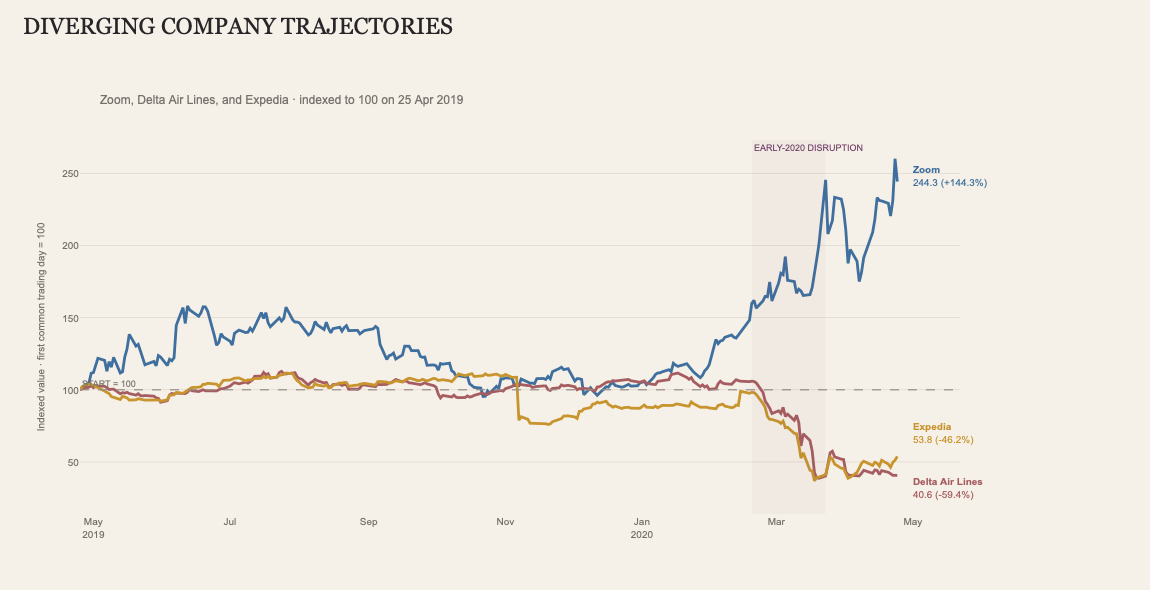

In [42]:
# -------------------------------------------------------------------
# Selected companies — diverging relative performance
# Each stock is indexed to 100 on the first common trading day.
# -------------------------------------------------------------------

COMPANY_COLORS = {
    "Zoom": "#3E6F9E",
    "Delta Air Lines": "#A65D61",
    "Expedia": "#C8942E",
}

FIN_PAPER = "#F6F1E8"
FIN_INK = "#282529"
FIN_MUTED = "#77706C"
FIN_GRID = "#DED6CC"


fig = go.Figure()


for company in [
    "Zoom",
    "Delta Air Lines",
    "Expedia",
]:

    fig.add_trace(
        go.Scatter(
            x=company_indexed["Date"],
            y=company_indexed[company],

            mode="lines",

            line=dict(
                color=COMPANY_COLORS[company],
                width=2.8,
            ),

            name=company,

            hovertemplate=(
                f"<b>{company}</b><br>"
                "%{x|%d %b %Y}<br>"
                "Indexed value: %{y:.1f}"
                "<extra></extra>"
            ),
        )
    )


# Common starting level
fig.add_hline(
    y=100,

    line_width=1.2,
    line_dash="dash",
    line_color="#968E88",

    annotation_text="START = 100",
    annotation_position="top left",

    annotation_font=dict(
        family="Arial",
        size=9,
        color=FIN_MUTED,
    ),
)


# Early-2020 disruption window
fig.add_vrect(
    x0="2020-02-19",
    x1="2020-03-23",

    fillcolor="#6F3E68",
    opacity=0.045,

    line_width=0,

    annotation_text="EARLY-2020 DISRUPTION",
    annotation_position="top left",

    annotation_font=dict(
        family="Arial",
        size=9,
        color="#6F3E68",
    ),
)


# Direct endpoint labels
last_row = company_indexed.iloc[-1]

label_offsets = {
    "Zoom": 0,
    "Expedia": 18,
    "Delta Air Lines": -18,
}

for company in [
    "Zoom",
    "Expedia",
    "Delta Air Lines",
]:

    ending_value = last_row[company]
    total_change = ending_value - 100

    fig.add_annotation(
        x=last_row["Date"],
        y=ending_value,

        text=(
            f"<b>{company}</b><br>"
            f"{ending_value:.1f} "
            f"({total_change:+.1f}%)"
        ),

        xshift=14,
        yshift=label_offsets[company],

        xanchor="left",

        showarrow=False,

        align="left",

        font=dict(
            family="Arial",
            size=10,
            color=COMPANY_COLORS[company],
        ),
    )


fig.update_layout(
    title=dict(
        text="DIVERGING COMPANY TRAJECTORIES",
        x=0.02,
        xanchor="left",
        y=0.97,
        yanchor="top",
        font=dict(
            family="Georgia",
            size=23,
            color=FIN_INK,
        ),
    ),

    paper_bgcolor=FIN_PAPER,
    plot_bgcolor=FIN_PAPER,

    height=590,

    margin=dict(
        l=80,
        r=190,
        t=140,
        b=70,
    ),

    font=dict(
        family="Arial",
        color=FIN_INK,
    ),

    showlegend=False,
)


fig.add_annotation(
    text=(
        "Zoom, Delta Air Lines, and Expedia · "
        "indexed to 100 on 25 Apr 2019"
    ),

    x=0.02,
    y=1.085,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=12,
        color=FIN_MUTED,
    ),
)


fig.update_xaxes(
    title="",

    showgrid=False,
    zeroline=False,

    tickformat="%b\n%Y",

    range=[
        company_indexed["Date"].min(),
        pd.Timestamp("2020-05-22"),
    ],

    tickfont=dict(
        size=10,
        color=FIN_MUTED,
    ),
)


fig.update_yaxes(
    title="Indexed value · first common trading day = 100",

    showgrid=True,
    gridcolor=FIN_GRID,
    gridwidth=0.7,

    zeroline=False,

    tickfont=dict(
        size=10,
        color=FIN_MUTED,
    ),

    title_font=dict(
        size=10,
        color=FIN_MUTED,
    ),
)


fig.show()

The historical series show sharply different trajectories. Zoom appreciated
substantially relative to its starting level, while Delta Air Lines and Expedia
declined sharply during early 2020.

The original project related these patterns to increased reliance on
videoconferencing and disruption to travel. In the restored analysis, that
explanation is treated as contextual interpretation rather than evidence that
the pandemic alone caused the observed price movements.

### Gold prices

The original financial analysis also examined monthly gold prices to explore
whether their movement during early 2020 appeared distinctive relative to the
preceding year.

The historical gold-price dataset is included in this repository with documented
provenance, so this portion of the restored analysis remains directly
reproducible.

In [43]:
gold = pd.read_csv(
    RAW_DATA_DIR / "gold_monthly.csv"
)

gold["Date"] = pd.to_datetime(
    gold["Date"],
    format="%Y-%m",
)

gold_period = (
    gold[
        (gold["Date"] >= "2019-01-01")
        & (gold["Date"] <= "2020-03-31")
    ]
    .sort_values("Date")
    .copy()
)

gold_period

,Date,Price
828,2019-01-01,1291.630
829,2019-02-01,1319.755
830,2019-03-01,1302.286
831,2019-04-01,1287.650
832,2019-05-01,1282.460
833,2019-06-01,1358.488
834,2019-07-01,1414.611
835,2019-08-01,1497.102
836,2019-09-01,1510.336
837,2019-10-01,1494.765


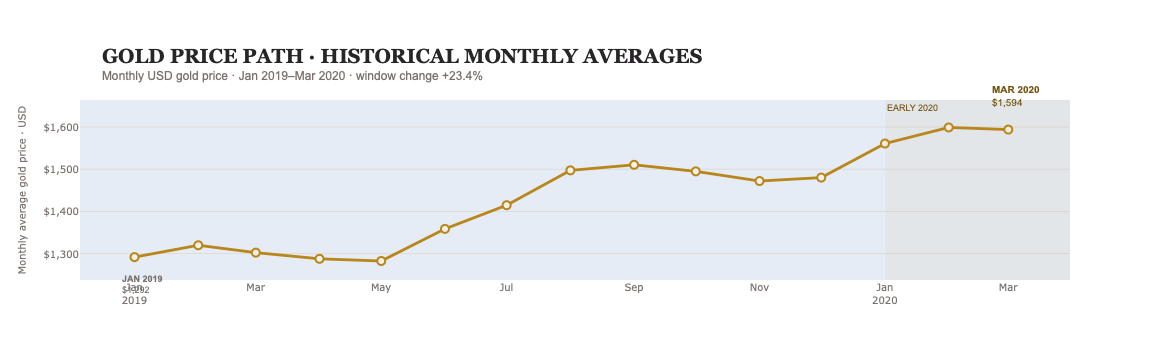

In [44]:
# -------------------------------------------------------------------
# Monthly gold prices — historical price path
# Jan 2019 through Mar 2020
# -------------------------------------------------------------------

GOLD = "#B8861B"
GOLD_DARK = "#765514"
GOLD_PAPER = "#F6F1E8"
GOLD_INK = "#282529"
GOLD_MUTED = "#77706C"
GOLD_GRID = "#DED6CC"


fig = go.Figure()


# Monthly gold-price path
fig.add_trace(
    go.Scatter(
        x=gold_period["Date"],
        y=gold_period["Price"],

        mode="lines",

        line=dict(
            color=GOLD,
            width=2.8,
        ),


        hovertemplate=(
            "<b>%{x|%B %Y}</b><br>"
            "Average gold price: $%{y:,.2f}"
            "<extra></extra>"
        ),

        showlegend=False,
    )
)


# Monthly observations
fig.add_trace(
    go.Scatter(
        x=gold_period["Date"],
        y=gold_period["Price"],

        mode="markers",

        marker=dict(
            size=8,
            color=GOLD_PAPER,
            line=dict(
                color=GOLD,
                width=2,
            ),
        ),

        hovertemplate=(
            "<b>%{x|%B %Y}</b><br>"
            "Average gold price: $%{y:,.2f}"
            "<extra></extra>"
        ),

        showlegend=False,
    )
)


# Highlight the beginning of 2020 descriptively
fig.add_vrect(
    x0="2020-01-01",
    x1="2020-03-31",

    fillcolor=GOLD,
    opacity=0.055,

    line_width=0,

    annotation_text="EARLY 2020",
    annotation_position="top left",

    annotation_font=dict(
        family="Arial",
        size=9,
        color=GOLD_DARK,
    ),
)



# Starting observation
first_row = gold_period.iloc[0]

fig.add_annotation(
    x=first_row["Date"],
    y=first_row["Price"],

    text=(
        f"<b>JAN 2019</b><br>"
        f"${first_row['Price']:,.0f}"
    ),

    xshift=8,
    yshift=-32,

    showarrow=False,

    align="left",

    font=dict(
        family="Arial",
        size=9,
        color=GOLD_MUTED,
    ),
)


# Ending observation
last_row = gold_period.iloc[-1]

fig.add_annotation(
    x=last_row["Date"],
    y=last_row["Price"],

    text=(
        f"<b>MAR 2020</b><br>"
        f"${last_row['Price']:,.0f}"
    ),

    xshift=8,
    yshift=28,

    showarrow=False,

    align="left",

    font=dict(
        family="Arial",
        size=10,
        color=GOLD_DARK,
    ),
)


# Change across the preserved window
price_change = (
    (last_row["Price"] / first_row["Price"]) - 1
) * 100


fig.add_annotation(
    text="<b>GOLD PRICE PATH · HISTORICAL MONTHLY AVERAGES</b>",
    x=0.02,
    y=1.17,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="bottom",
    showarrow=False,
    font=dict(
        family="Georgia",
        size=20,
        color=GOLD_INK,
    ),
)


fig.add_annotation(
    text=(
        "Monthly USD gold price · Jan 2019–Mar 2020 · "
        f"window change {price_change:+.1f}%"
    ),

    x=0.02,
    y=1.09,

    xref="paper",
    yref="paper",

    xanchor="left",
    yanchor="bottom",

    showarrow=False,

    font=dict(
        family="Arial",
        size=12,
        color=GOLD_MUTED,
    ),
)


fig.update_xaxes(
    title="",

    showgrid=False,
    zeroline=False,

    tickformat="%b\n%Y",

    tickfont=dict(
        size=10,
        color=GOLD_MUTED,
    ),
)


fig.update_yaxes(
    title="Monthly average gold price · USD",

    showgrid=True,
    gridcolor=GOLD_GRID,
    gridwidth=0.7,

    zeroline=False,

    tickprefix="$",
    tickformat=",.0f",

    # Avoid filling visually all the way down from zero.
    range=[
        gold_period["Price"].min() - 45,
        gold_period["Price"].max() + 65,
    ],

    tickfont=dict(
        size=10,
        color=GOLD_MUTED,
    ),

    title_font=dict(
        size=10,
        color=GOLD_MUTED,
    ),
)


fig.show()

Gold prices were already trending upward during portions of 2019, with some
intermediate declines, and remained elevated into early 2020.

The limited monthly series does not demonstrate that the pandemic itself caused
the observed movement in gold prices. The restored analysis therefore retains
the original descriptive comparison without assigning a causal explanation.

## 06 · Limitations & Conclusion

### Limitations

This project was developed during the first months of the COVID-19 pandemic,
when both the disease and the available public datasets were changing rapidly.
The results should therefore be understood as a **historical analytical
snapshot**, not as a retrospective assessment using everything that became
known later.

Several limitations apply across the analysis:

- **Reported cases are not equivalent to true infections.** Testing availability,
  eligibility, reporting practices, and data completeness varied substantially
  across countries, US states, and time periods.

- **The observation windows differ slightly across datasets.** Most COVID-19 analysis extends through approximately May 12–13, 2020, while the preserved US daily-case series ends on May 11. The recovered company-price series extends through April 24, 2020, and the monthly gold series through March 2020.

- **Population-adjusted comparisons use 2018 population figures**, consistent
  with the data available to the original project.

- **Recent observations can be affected by reporting delays.** This is
  particularly important when interpreting the final days of the NYC daily
  case, hospitalization, and death series.

- **Cross-sectional regression identifies associations, not causal effects.**
  The state-level models use only 51 observations and show diagnostic concerns
  including non-normal residuals and large condition numbers.

- **Financial-market comparisons are descriptive.** Concurrent price movements
  cannot by themselves establish that the pandemic caused a particular market
  or company response.

  
- **Reproducibility differs across the financial subsections.** The original company-price files for Zoom, Delta Air Lines, and Expedia, as well as the historical gold dataset, were recovered and can be reproduced directly. The complete 2019–2020 source files used for the market-index comparison were not recovered, so that comparison is retained as a preserved historical figure rather than being recomputed from incomplete source files.

- **Historical datasets evolved after the project was submitted.** The restored
  version therefore uses pinned or locally preserved snapshots where possible
  rather than silently substituting later revisions.

### Conclusion

This project explored the first wave of COVID-19 from several analytical
perspectives: global and US case patterns, the outbreak in New York City,
state-level testing relationships, and financial-market behavior.

The global analysis showed how rapidly the geographic concentration of reported
cases shifted during the opening months of the pandemic. Population-adjusted
comparisons also showed how absolute case counts alone can provide an incomplete view of cross-country burden.

Within the United States, reported cases were highly concentrated across a
relatively small number of states by mid-May 2020, while daily national case
counts illustrated both the rapid March increase and substantial day-to-day
reporting volatility.

New York City data provided a more detailed view of the first major urban
outbreak. Reported cases, hospitalizations, and deaths rose sharply before
declining within the historical observation window, while age-stratified data
showed especially large differences in severe-outcome rates across age groups.
The historical snapshot also showed higher reported hospitalization and death
rates for males than females.

The exploratory state-level regression suggested that physician count,
population, and income were associated with differences in reported testing
volume in the original data. Physician count showed the strongest individual
relationship, while the reduced multiple-regression model combining physicians
and population retained most of the explanatory power of the larger model.
These findings remain exploratory associations rather than evidence of causal
effects.

Finally, the financial analysis showed markedly different market trajectories
during early 2020. Major US indices experienced a sharp decline followed by a
partial recovery, while Zoom diverged substantially from Delta Air Lines and
Expedia. Gold prices were already following a broader upward trend before the
most acute pandemic period, illustrating why contemporaneous movement should
not automatically be attributed to COVID-19.

Taken together, the project shows how multiple public datasets and analytical approaches can be combined to examine a rapidly developing event. The restored version preserves the original questions, historical period, collaborative scope, and analytical intent of the Spring 2020 project while improving reproducibility, visual communication, code clarity, and the precision of the interpretation.